# Have Rents Actually Fallen — And How Much of the Run-Up Has Reversed?

Canadian asking rents have fallen from their recent peaks in most large
cities. The headline framing tends to stop there. This notebook asks the
next question directly:

> **Canadian asking rents have recently declined in many cities, but how
> large is that decline relative to the preceding increase, and how much of
> the earlier run-up has actually been reversed?**

We use two complementary sources throughout:

- **StatCan asking rents** (quarterly, Q1 2019 – latest quarter) — rents
  advertised for new listings, a fast-moving leading indicator. We use the
  **2-bedroom apartment** series for every city.
- **CMHC primary-market average rent** (annual, back to 1990 for most CMAs)
  — the average rent paid across the *entire* occupied purpose-built rental
  stock (all bedroom types combined; CMHC does not publish a CMA-level
  2-bedroom breakout in this dataset). Slower-moving, but a much longer
  history and a broader population of renters.

**Working expectation, not an assumed conclusion:** the decline is real and
geographically widespread, but modest relative to the increase since 2019 —
most of the earlier dollar increase is still in place. Every section below
reports what the data actually show; the conclusion is revised if the
evidence points elsewhere.

**Notebook structure:**
1. Data and definitions
2. National trajectory
3. Peak-to-latest change
4. How much of the earlier increase was reversed?
5. Distribution across cities
6. Alternative comparison dates and robustness checks
7. Inflation-adjusted results
8. Comparison with CMHC occupied-rent data
9. Historical context
10. Main findings and limitations
11. Supplementary diagnostics

## 1 — Data and Definitions

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy import stats
from tqdm.notebook import tqdm

/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
ASKING_ROOT = Path('../../data/statscan-quarterly-rental-clean/can-cma-all')
CMHC_ROOT   = Path('../../data/cmhc-rental-clean/can-cma-primary/primary-summary')
REF_ROOT    = Path('../../data/reference')
REF_ROOT.mkdir(parents=True, exist_ok=True)

BED_TYPE = 'Apt 2br'   # unit type for the StatCan asking-rent series, used throughout
BASELINE_QUARTER = pd.Period('2019Q1')

# ── CPI, all-items, 2002=100 (Statistics Canada) — Canada + each province with
# a CMA in this dataset. No territories: none of the CMAs analyzed here are
# in Yukon, NWT, or Nunavut.
CPI_YEARS = list(range(1990, 2026))
PROVINCE_CPI_VALUES = {
    'Canada': [
        78.4,  82.8,  84.0,  85.6,  85.7,  87.6,  88.9,  90.4,  91.3,  92.9,
        95.4,  97.8, 100.0, 102.8, 104.7, 107.0, 109.1, 111.5, 114.1, 114.4,
       116.5, 119.9, 121.7, 122.8, 125.2, 126.6, 128.4, 130.4, 133.4, 136.0,
       137.0, 141.6, 151.2, 157.1, 160.9, 164.2,
    ],
    'Newfoundland and Labrador': [
        79.5,  84.4,  85.3,  86.7,  87.8,  89.0,  90.4,  92.3,  92.5,  93.8,
        96.6,  97.7, 100.0, 102.9, 104.8, 107.6, 109.5, 111.1, 114.3, 114.6,
       117.4, 121.4, 123.9, 126.0, 128.4, 129.0, 132.5, 135.7, 137.9, 139.3,
       139.6, 144.7, 153.9, 159.0, 161.9, 164.2,
    ],
    'Prince Edward Island': [
        78.4,  84.3,  85.0,  86.6,  86.4,  87.8,  89.4,  90.5,  90.1,  91.2,
        94.9,  97.4, 100.0, 103.5, 105.8, 109.1, 111.6, 113.6, 117.5, 117.3,
       119.5, 123.0, 125.5, 128.0, 130.1, 129.3, 130.8, 133.2, 136.3, 137.9,
       137.9, 144.9, 157.8, 162.3, 165.3, 167.6,
    ],
    'Nova Scotia': [
        78.2,  82.9,  83.5,  84.5,  85.5,  86.6,  88.2,  90.0,  90.6,  92.1,
        95.3,  97.1, 100.0, 103.4, 105.3, 108.2, 110.4, 112.5, 115.9, 115.7,
       118.2, 122.7, 125.1, 126.6, 128.8, 129.3, 130.9, 132.4, 135.3, 137.5,
       137.9, 143.5, 154.3, 160.5, 164.2, 167.6,
    ],
    'New Brunswick': [
        78.7,  83.8,  84.3,  85.4,  85.9,  87.2,  88.5,  90.1,  90.6,  92.1,
        95.1,  96.8, 100.0, 103.4, 104.9, 107.4, 109.2, 111.3, 113.2, 113.5,
       115.9, 120.0, 122.0, 123.0, 124.8, 125.4, 128.2, 131.2, 134.0, 136.3,
       136.6, 141.8, 152.1, 157.5, 161.0, 163.7,
    ],
    'Quebec': [
        79.2,  85.0,  86.6,  87.7,  86.6,  88.1,  89.5,  90.8,  92.1,  93.5,
        95.8,  98.0, 100.0, 102.5, 104.5, 106.9, 108.7, 110.4, 112.7, 113.4,
       114.8, 118.3, 120.8, 121.7, 123.4, 124.7, 125.6, 126.9, 129.0, 131.7,
       132.8, 137.8, 147.0, 153.6, 157.2, 161.0,
    ],
    'Ontario': [
        78.7,  82.4,  83.2,  84.7,  84.7,  86.8,  88.2,  89.8,  90.6,  92.4,
        95.1,  98.0, 100.0, 102.7, 104.6, 106.9, 108.8, 110.8, 113.3, 113.7,
       116.5, 120.1, 121.8, 123.0, 125.9, 127.4, 129.7, 131.9, 135.0, 137.5,
       138.4, 143.2, 152.9, 158.7, 162.5, 165.6,
    ],
    'Manitoba': [
        76.2,  80.1,  81.2,  83.4,  84.6,  86.9,  88.8,  90.6,  91.8,  93.6,
        95.9,  98.5, 100.0, 101.8, 103.8, 106.6, 108.7, 110.9, 113.4, 114.1,
       115.0, 118.4, 120.3, 123.0, 125.3, 126.8, 128.4, 130.5, 133.8, 136.8,
       137.5, 142.0, 153.2, 158.6, 160.3, 164.6,
    ],
    'Saskatchewan': [
        76.0,  80.0,  80.8,  83.3,  84.8,  86.4,  88.1,  89.2,  90.4,  92.0,
        94.4,  97.2, 100.0, 102.3, 104.6, 106.9, 109.1, 112.2, 115.9, 117.1,
       118.7, 122.0, 123.9, 125.7, 128.7, 130.8, 132.2, 134.4, 137.5, 139.9,
       140.7, 144.4, 153.9, 160.0, 162.3, 165.7,
    ],
    'Alberta': [
        75.0,  79.4,  80.6,  81.4,  82.6,  84.5,  86.4,  88.1,  89.2,  91.4,
        94.5,  96.7, 100.0, 104.4, 105.9, 108.1, 112.3, 117.9, 121.6, 121.5,
       122.7, 125.7, 127.1, 128.9, 132.2, 133.7, 135.2, 137.3, 140.6, 143.1,
       144.7, 149.3, 158.9, 164.1, 168.9, 172.2,
    ],
    'British Columbia': [
        78.4,  82.6,  84.8,  87.8,  89.5,  91.6,  92.4,  93.1,  93.4,  94.4,
        96.1,  97.7, 100.0, 102.2, 104.2, 106.3, 108.1, 110.0, 112.3, 112.3,
       113.8, 116.5, 117.8, 117.7, 118.9, 120.2, 122.4, 125.0, 128.4, 131.4,
       132.4, 136.1, 145.5, 151.2, 155.2, 158.5,
    ],
}
CPI_BY_PROVINCE = pd.DataFrame(PROVINCE_CPI_VALUES, index=CPI_YEARS)
CPI_BY_PROVINCE.index.name = 'Year'
CPI_CANADA = CPI_BY_PROVINCE['Canada']

# Every CMA in this dataset, mapped to the province its CPI series should
# come from (Ottawa and Gatineau are the Ontario/Quebec halves of one CMA;
# no territories have a CMA in this dataset).
CMA_PROVINCE = {
    'abbotsford-mission':            'British Columbia',
    'barrie':                        'Ontario',
    'belleville-quinte west':        'Ontario',
    'brantford':                     'Ontario',
    'calgary':                       'Alberta',
    'chilliwack':                    'British Columbia',
    'drummondville':                 'Quebec',
    'edmonton':                      'Alberta',
    'fredericton':                   'New Brunswick',
    'gatineau':                      'Quebec',
    'greater sudbury':               'Ontario',
    'guelph':                        'Ontario',
    'halifax':                       'Nova Scotia',
    'hamilton':                      'Ontario',
    'kamloops':                      'British Columbia',
    'kelowna':                       'British Columbia',
    'kingston':                      'Ontario',
    'kitchener-cambridge-waterloo':  'Ontario',
    'lethbridge':                    'Alberta',
    'london':                        'Ontario',
    'moncton':                       'New Brunswick',
    'montreal':                      'Quebec',
    'nanaimo':                       'British Columbia',
    'oshawa':                        'Ontario',
    'ottawa':                        'Ontario',
    'peterborough':                  'Ontario',
    'quebec':                        'Quebec',
    'red deer':                      'Alberta',
    'regina':                        'Saskatchewan',
    'saguenay':                      'Quebec',
    'saint john':                    'New Brunswick',
    'saskatoon':                     'Saskatchewan',
    'sherbrooke':                    'Quebec',
    'st. catharines-niagara':        'Ontario',
    "st. john's":                    'Newfoundland and Labrador',
    'thunder bay':                   'Ontario',
    'toronto':                       'Ontario',
    'trois-rivieres':                'Quebec',
    'vancouver':                     'British Columbia',
    'victoria':                      'British Columbia',
    'windsor':                       'Ontario',
    'winnipeg':                      'Manitoba',
}


def city_cpi(city: str) -> pd.Series:
    return CPI_BY_PROVINCE[CMA_PROVINCE[city]]

# CMHC file name -> StatCan file name, where the two datasets spell the
# same CMA differently.
CMHC_TO_STATCAN_NAME = {
    'quebec city': 'quebec',
    "st john's":   "st. john's",
}

# Descriptive thresholds for "materially" below peak — sensitivity guides,
# not statistical cutoffs (see Section 6).
DESCRIPTIVE_THRESHOLDS = [2.0, 5.0, 10.0]

# Cities featured in the main-notebook small multiples; the full 40-city
# grid lives in Section 11 (Supplementary).
FEATURED_CITIES = ['toronto', 'vancouver', 'montreal', 'calgary', 'ottawa',
                    'halifax', 'edmonton', 'winnipeg', 'kitchener-cambridge-waterloo',
                    'regina', 'victoria', "st. john's"]

BOOTSTRAP_N = 5000
BOOTSTRAP_SEED = 20260723

# ── Chart style (reference palette, consistent with other notebooks) ────
C1 = '#2a78d6'  # blue   — headline / nominal series
C2 = '#1baf7a'  # aqua   — real / CPI-adjusted series
C3 = '#eda100'  # yellow — secondary comparator / CMHC
C4 = '#008300'  # green  — decline / below-peak
C5 = '#4a3aa7'  # violet — secondary metric (vacancy, etc.)
C6 = '#e34948'  # red    — rise / at-or-above peak

SURFACE  = '#fcfcfb'
INK      = '#0b0b0b'
INK2     = '#52514e'
MUTED    = '#898781'
GRID_CLR = '#e1e0d9'

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.edgecolor':    GRID_CLR,
    'axes.labelcolor':   INK2,
    'xtick.color':       INK2,
    'ytick.color':       INK2,
    'grid.color':        GRID_CLR,
    'grid.linewidth':    0.5,
    'figure.facecolor':  SURFACE,
    'axes.facecolor':    SURFACE,
})

### Definitions used throughout

For the national series and every CMA we compute, from the StatCan 2-bedroom
asking-rent series:

| Quantity | Meaning |
|---|---|
| `first_value` / `first_period` | Earliest available observation |
| `y2019_value` | Q1 2019 value, where available (else the earliest observation, flagged) |
| `peak_value` / `peak_period` | Highest quarterly value on record |
| `latest_value` / `latest_period` | Most recent observation |
| `increase_2019_to_peak` ($, %) | Rise from the 2019 baseline to the peak |
| `decline_peak_to_latest` ($, %) | Fall from the peak to the latest quarter |
| `net_change_2019_to_latest` ($, %) | Net change from the 2019 baseline to today |
| `share_reversed` | **The preferred public-facing measure** — see below |

**Share of the earlier increase reversed**, in dollar terms:

$$\text{share reversed} = \frac{\text{peak rent} - \text{latest rent}}{\text{peak rent} - \text{2019 rent}} \times 100$$

This is deliberately **not** a comparison of two percentage changes with
different denominators (increase as % of the 2019 level vs. decline as % of
the peak level) — it asks what fraction of the *dollar* climb has come back
down, which is the number a reader actually needs to judge "how much of the
run-up is gone." Where a city lacks a Q1 2019 observation, the alternative
starting point is reported explicitly and the reversed-share figure is
flagged rather than treated as directly comparable to cities with a full
2019 baseline.

### Loading the data

One StatCan asking-rent series per CMA plus StatCan's own pre-built
**"All CMAs"** national aggregate, and one CMHC primary-market annual series
per CMA (average rent, median rent, vacancy rate).

In [3]:
def parse_quarter(label: str) -> pd.Period:
    q, y = label.split()
    return pd.Period(f'{y}{q}', freq='Q')


def load_asking(fp: Path) -> pd.Series:
    df = pd.read_csv(fp)
    df['period'] = df['Quarter'].map(parse_quarter)
    return df.set_index('period')[BED_TYPE].sort_index().dropna().rename(fp.stem)


asking_files = sorted(p for p in ASKING_ROOT.glob('*.csv') if p.stem != 'all')
asking = {p.stem: s for p in tqdm(asking_files, desc='asking rents')
          if len(s := load_asking(p)) >= 8}
asking_national = load_asking(ASKING_ROOT / 'all.csv')

skipped = [p.stem for p in asking_files if p.stem not in asking]
print(f'{len(asking)} CMAs loaded ({len(skipped)} skipped for too little 2BR data: {skipped})')
print(f'National series: {asking_national.index.min()} - {asking_national.index.max()}')

asking rents:   0%|          | 0/42 [00:00<?, ?it/s]

40 CMAs loaded (2 skipped for too little 2BR data: ['saguenay', 'trois-rivieres'])
National series: 2019Q1 - 2026Q1


In [4]:
def load_cmhc(fp: Path) -> pd.DataFrame:
    return pd.read_csv(fp).set_index('Year').sort_index()


cmhc_files = sorted(CMHC_ROOT.glob('*.csv'))
cmhc = {}
for fp in tqdm(cmhc_files, desc='CMHC primary market'):
    name = CMHC_TO_STATCAN_NAME.get(fp.stem, fp.stem)
    df = load_cmhc(fp)
    if df['Average Rent'].notna().sum() < 5:
        continue
    cmhc[name] = df

print(f'{len(cmhc)} CMAs with usable CMHC history (of {len(cmhc_files)} files)')
print(f'Columns available: {list(next(iter(cmhc.values())).columns)}')

CMHC primary market:   0%|          | 0/42 [00:00<?, ?it/s]

40 CMAs with usable CMHC history (of 42 files)
Columns available: ['Vacancy Rate', 'Availability Rate', 'Average Rent', 'Median Rent', 'Pct Change', 'Units']


### Inflation adjustment: quarterly-interpolated CPI

The earlier version of this notebook applied a single **annual** CPI value
to all four quarters of a year — a coarse approximation that creates
artificial flat steps and slightly overstates real change right around each
year boundary. No monthly provincial CPI series is available in this repo,
so instead we **linearly interpolate between annual CPI observations**,
placing each annual value at Q2 (the mid-year point) and interpolating
quarter-by-quarter between consecutive years. This is still an
approximation — it assumes inflation accrued smoothly through the year
rather than in the actual monthly pattern — but it removes the artificial
step function and is documented here rather than left implicit. Every
series is deflated using **each CMA's own province's** CPI (national series
uses the Canada column), and rescaled into constant dollars of the latest
CPI year available.

In [5]:
def cpi_quarterly(cpi_annual: pd.Series) -> pd.Series:
    """Interpolate an annual CPI series to quarterly, treating each annual
    value as the Q2 (mid-year) observation and linearly interpolating
    between years. Held flat before the first / after the last knot."""
    knots = pd.PeriodIndex([pd.Period(f'{y}Q2') for y in cpi_annual.index], freq='Q')
    knot_series = pd.Series(cpi_annual.values, index=knots)
    full_range = pd.period_range(knots.min(), knots.max(), freq='Q')
    return knot_series.reindex(full_range).interpolate(method='linear').ffill().bfill()


CPI_CANADA_Q = cpi_quarterly(CPI_CANADA)
CPI_BY_PROVINCE_Q = {prov: cpi_quarterly(CPI_BY_PROVINCE[prov]) for prov in CPI_BY_PROVINCE.columns}


def city_cpi_q(city: str) -> pd.Series:
    return CPI_BY_PROVINCE_Q[CMA_PROVINCE[city]]


def deflate_quarterly(series: pd.Series, cpi_q: pd.Series) -> pd.Series:
    base_q = cpi_q.index.max()
    idx = series.index.map(lambda p: p if p in cpi_q.index else cpi_q.index.max())
    cpi_vals = pd.Series(cpi_q.reindex(idx).values, index=series.index)
    return series * (cpi_q[base_q] / cpi_vals)


def deflate_annual(series: pd.Series, cpi_annual: pd.Series) -> pd.Series:
    base_year = cpi_annual.index.max()
    cpi_vals = cpi_annual.reindex(series.index).ffill()
    return series * (cpi_annual[base_year] / cpi_vals)


print(f'Deflating quarterly series to constant {CPI_CANADA_Q.index.max()} dollars,')
print('using linear interpolation between annual CPI observations (each city its own province).')

Deflating quarterly series to constant 2025Q2 dollars,
using linear interpolation between annual CPI observations (each city its own province).


In [6]:
CPI_BY_PROVINCE.reset_index().to_csv(REF_ROOT / 'cpi_by_province.csv', index=False)
CPI_CANADA.rename_axis('Year').reset_index().to_csv(REF_ROOT / 'cpi_canada.csv', index=False)
print('Wrote cpi_by_province.csv, cpi_canada.csv to data/reference/')

Wrote cpi_by_province.csv, cpi_canada.csv to data/reference/


## 2 — National Trajectory

In [7]:
def peak_stats(series: pd.Series, baseline_period=None) -> dict:
    peak_p, latest_p = series.idxmax(), series.index.max()
    peak_v, latest_v = series[peak_p], series[latest_p]
    first_p = series.index.min()
    first_v = series[first_p]
    used_alt_start = baseline_period is not None and baseline_period not in series.index
    base_p = baseline_period if (baseline_period is not None and baseline_period in series.index) else first_p
    base_v = series[base_p]
    increase_d = peak_v - base_v
    increase_pct = increase_d / base_v * 100
    decline_d = latest_v - peak_v
    decline_pct = decline_d / peak_v * 100
    net_d = latest_v - base_v
    net_pct = net_d / base_v * 100
    share_reversed = (peak_v - latest_v) / increase_d * 100 if increase_d > 0 else np.nan
    return dict(
        first_period=first_p, first_value=first_v,
        base_period=base_p, base_value=base_v, used_alt_start=used_alt_start,
        peak_period=peak_p, peak_value=peak_v,
        latest_period=latest_p, latest_value=latest_v,
        increase_2019_to_peak_d=increase_d, increase_2019_to_peak_pct=increase_pct,
        decline_peak_to_latest_d=decline_d, decline_peak_to_latest_pct=decline_pct,
        net_change_d=net_d, net_change_pct=net_pct,
        share_reversed=share_reversed,
        periods_since_peak=(latest_p.ordinal - peak_p.ordinal) if hasattr(latest_p, 'ordinal') else (latest_p - peak_p),
    )


national_nom = peak_stats(asking_national, BASELINE_QUARTER)

print('National (All CMAs) — 2BR asking rent, nominal')
print('-' * 68)
print(f'  First observation:  {national_nom["first_period"]}  ${national_nom["first_value"]:.0f}')
print(f'  2019 baseline:      {national_nom["base_period"]}  ${national_nom["base_value"]:.0f}')
print(f'  Peak:               {national_nom["peak_period"]}  ${national_nom["peak_value"]:.0f}'
      f'  ({national_nom["increase_2019_to_peak_pct"]:+.1f}% vs. 2019, '
      f'+${national_nom["increase_2019_to_peak_d"]:.0f})')
print(f'  Latest:              {national_nom["latest_period"]}  ${national_nom["latest_value"]:.0f}'
      f'  ({national_nom["decline_peak_to_latest_pct"]:+.1f}% vs. peak, '
      f'${national_nom["decline_peak_to_latest_d"]:+.0f})')
print(f'  Net 2019 -> latest:  {national_nom["net_change_pct"]:+.1f}%  (${national_nom["net_change_d"]:+.0f})')
print(f'  Share of the 2019->peak dollar increase reversed so far: '
      f'{national_nom["share_reversed"]:.1f}%')

National (All CMAs) — 2BR asking rent, nominal
--------------------------------------------------------------------
  First observation:  2019Q1  $1520
  2019 baseline:      2019Q1  $1520
  Peak:               2023Q4  $2250  (+48.0% vs. 2019, +$730)
  Latest:              2026Q1  $2150  (-4.4% vs. peak, $-100)
  Net 2019 -> latest:  +41.4%  ($+630)
  Share of the 2019->peak dollar increase reversed so far: 13.7%


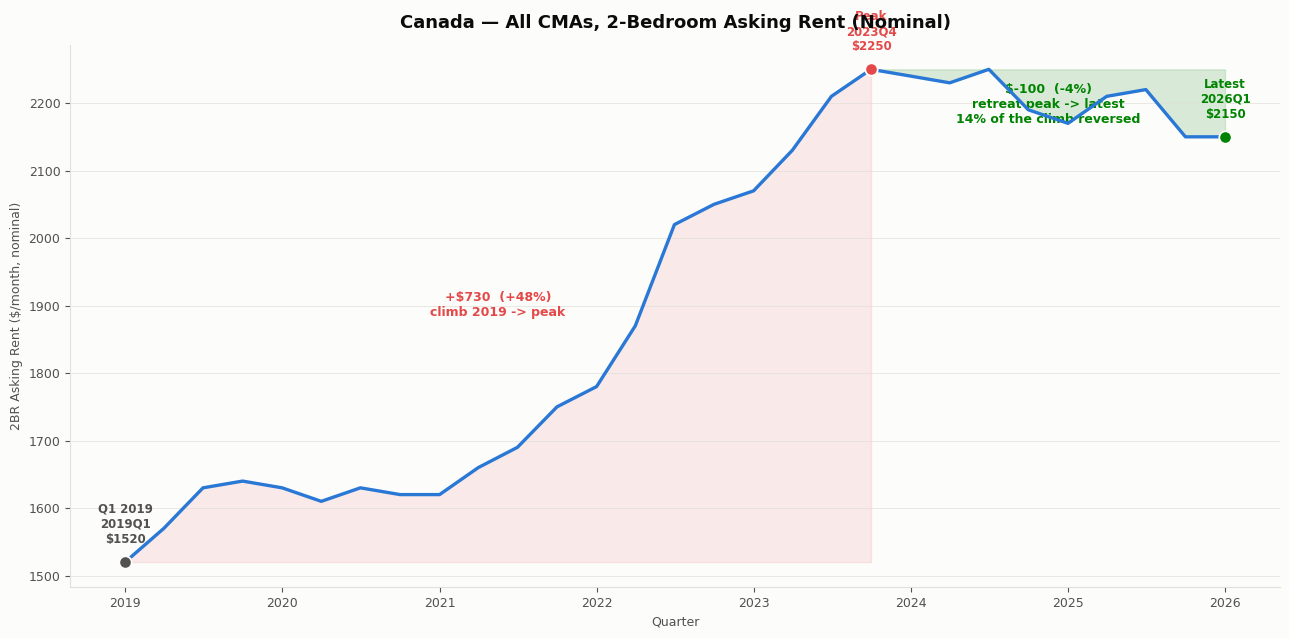

In [8]:
x = asking_national.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(x, asking_national.values, color=C1, linewidth=2.4, zorder=5)
ax.fill_between(x, asking_national.values, national_nom['base_value'],
                 where=(asking_national.index <= national_nom['peak_period']),
                 color=C6, alpha=0.10, zorder=1)
ax.fill_between(x, asking_national.values, national_nom['peak_value'],
                 where=(asking_national.index >= national_nom['peak_period']),
                 color=C4, alpha=0.14, zorder=1)

for label, period, value, color in [
    ('Q1 2019', national_nom['base_period'], national_nom['base_value'], INK2),
    ('Peak', national_nom['peak_period'], national_nom['peak_value'], C6),
    ('Latest', national_nom['latest_period'], national_nom['latest_value'], C4),
]:
    px = period.to_timestamp()
    ax.scatter([px], [value], color=color, s=80, zorder=6, edgecolors=SURFACE, linewidths=1.3)
    ax.annotate(f'{label}\n{period}\n${value:.0f}', (px, value), xytext=(0, 14),
                textcoords='offset points', fontsize=8.5, color=color, ha='center',
                fontweight='bold')

mid_up_x = national_nom['base_period'].to_timestamp() + (
    national_nom['peak_period'].to_timestamp() - national_nom['base_period'].to_timestamp()) / 2
ax.annotate(f'+${national_nom["increase_2019_to_peak_d"]:.0f}  '
            f'({national_nom["increase_2019_to_peak_pct"]:+.0f}%)\nclimb 2019 -> peak',
            (mid_up_x, (national_nom['base_value'] + national_nom['peak_value']) / 2),
            fontsize=9, color=C6, ha='center', fontweight='bold')

mid_dn_x = national_nom['peak_period'].to_timestamp() + (
    national_nom['latest_period'].to_timestamp() - national_nom['peak_period'].to_timestamp()) / 2
ax.annotate(f'${national_nom["decline_peak_to_latest_d"]:.0f}  '
            f'({national_nom["decline_peak_to_latest_pct"]:+.0f}%)\nretreat peak -> latest\n'
            f'{national_nom["share_reversed"]:.0f}% of the climb reversed',
            (mid_dn_x, national_nom['peak_value'] * 0.965),
            fontsize=9, color=C4, ha='center', fontweight='bold')

ax.set_ylabel('2BR Asking Rent ($/month, nominal)', fontsize=9)
ax.set_xlabel('Quarter', fontsize=9)
ax.set_title('Canada — All CMAs, 2-Bedroom Asking Rent (Nominal)', fontsize=13,
             fontweight='bold', color=INK, pad=12)
ax.grid(axis='y')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

This is the main public-facing chart: nominal 2-bedroom asking rent, Q1 2019
through the latest quarter, with the 2019 baseline, the peak, and the latest
observation marked, plus the dollar size of the climb and the retreat. A
nominal-versus-real (inflation-adjusted) version of this same chart appears
in Section 7.

## 3 — Peak-to-Latest Change: Every CMA

In [9]:
asking_rows = []
for city, series in asking.items():
    st = peak_stats(series, BASELINE_QUARTER)
    st['city'] = city
    asking_rows.append(st)

asking_peak = pd.DataFrame(asking_rows).set_index('city').sort_values('share_reversed', ascending=False)

n_alt_start = int(asking_peak['used_alt_start'].sum())
print(f'{len(asking_peak)} CMAs. {n_alt_start} lack a Q1 2019 observation and use an alternative '
      f'starting quarter instead (flagged in the `used_alt_start` column below); their '
      f'share_reversed figure is not directly comparable to cities with a full 2019 baseline.')
if n_alt_start:
    print(asking_peak.loc[asking_peak['used_alt_start'], ['first_period', 'base_period']])

40 CMAs. 0 lack a Q1 2019 observation and use an alternative starting quarter instead (flagged in the `used_alt_start` column below); their share_reversed figure is not directly comparable to cities with a full 2019 baseline.


In [10]:
SUMMARY_COLS = ['first_period', 'first_value', 'base_period', 'base_value', 'used_alt_start',
                'peak_period', 'peak_value', 'latest_period', 'latest_value',
                'increase_2019_to_peak_d', 'increase_2019_to_peak_pct',
                'decline_peak_to_latest_d', 'decline_peak_to_latest_pct',
                'net_change_d', 'net_change_pct', 'share_reversed']

summary_table = asking_peak[SUMMARY_COLS].round(1)
summary_table

,first_period,first_value,base_period,base_value,used_alt_start,peak_period,peak_value,latest_period,latest_value,increase_2019_to_peak_d,increase_2019_to_peak_pct,decline_peak_to_latest_d,decline_peak_to_latest_pct,net_change_d,net_change_pct,share_reversed
city,,,,,,,,,,,,,,,,
toronto,2019Q1,2560.0,2019Q1,2560.0,False,2023Q3,2920.0,2026Q1,2660.0,360.0,14.1,-260.0,-8.9,100.0,3.9,72.2
vancouver,2019Q1,2490.0,2019Q1,2490.0,False,2023Q3,3580.0,2026Q1,3100.0,1090.0,43.8,-480.0,-13.4,610.0,24.5,44.0
kelowna,2019Q1,1630.0,2019Q1,1630.0,False,2022Q3,2720.0,2026Q1,2320.0,1090.0,66.9,-400.0,-14.7,690.0,42.3,36.7
calgary,2019Q1,1360.0,2019Q1,1360.0,False,2024Q2,2150.0,2026Q1,1900.0,790.0,58.1,-250.0,-11.6,540.0,39.7,31.6
chilliwack,2019Q1,1220.0,2019Q1,1220.0,False,2024Q1,1840.0,2026Q1,1690.0,620.0,50.8,-150.0,-8.2,470.0,38.5,24.2
abbotsford-mission,2019Q1,1240.0,2019Q1,1240.0,False,2024Q3,2130.0,2026Q1,1920.0,890.0,71.8,-210.0,-9.9,680.0,54.8,23.6
kitchener-cambridge-waterloo,2019Q1,1450.0,2019Q1,1450.0,False,2023Q4,2300.0,2026Q1,2110.0,850.0,58.6,-190.0,-8.3,660.0,45.5,22.4
victoria,2019Q1,1810.0,2019Q1,1810.0,False,2023Q4,2760.0,2026Q1,2560.0,950.0,52.5,-200.0,-7.2,750.0,41.4,21.1
kingston,2019Q1,1380.0,2019Q1,1380.0,False,2024Q2,2060.0,2026Q1,1920.0,680.0,49.3,-140.0,-6.8,540.0,39.1,20.6


This is the clean summary table specified in the brief — every measure, for
every CMA, sorted by `share_reversed` (highest share of the earlier increase
undone, to lowest). Cities flagged `used_alt_start = True` had no Q1 2019
observation and instead use their earliest available quarter as the
baseline; their run-up and reversed-share figures describe a shorter window
than the other cities and should be read with that caveat.

## 4 — How Much of the Earlier Increase Was Reversed?

In [11]:
valid = asking_peak[asking_peak['increase_2019_to_peak_d'] > 0].copy()
sr = valid['share_reversed']

print(f'Share of the 2019 -> peak dollar increase reversed so far, {len(valid)} CMAs')
print('-' * 68)
print(f'  National:                {national_nom["share_reversed"]:.1f}%')
print(f'  Mean across CMAs:        {sr.mean():.1f}%')
print(f'  Median across CMAs:      {sr.median():.1f}%')
print(f'  Interquartile range:     {sr.quantile(0.25):.1f}% - {sr.quantile(0.75):.1f}%')
print(f'  Full range:              {sr.min():.1f}% - {sr.max():.1f}%')
print()
n = len(valid)
n_below_peak = int((valid['decline_peak_to_latest_pct'] < 0).sum())
print(f'  CMAs below their own peak at all:  {n_below_peak}/{n}  ({100*n_below_peak/n:.0f}%)')
for th in DESCRIPTIVE_THRESHOLDS:
    n_th = int((valid['decline_peak_to_latest_pct'] < -th).sum())
    print(f'  CMAs down more than {th:.0f}% from peak:   {n_th}/{n}  ({100*n_th/n:.0f}%)')
print()
n_majority_reversed = int((sr > 50).sum())
n_mostly_intact = int((sr < 25).sum())
print(f'  CMAs where MORE than half the run-up is reversed: {n_majority_reversed}/{n} ({100*n_majority_reversed/n:.0f}%)')
print(f'  CMAs where LESS than a quarter of the run-up is reversed: {n_mostly_intact}/{n} ({100*n_mostly_intact/n:.0f}%)')

Share of the 2019 -> peak dollar increase reversed so far, 40 CMAs
--------------------------------------------------------------------
  National:                13.7%
  Mean across CMAs:        14.7%
  Median across CMAs:      13.3%
  Interquartile range:     5.5% - 19.4%
  Full range:              0.0% - 72.2%

  CMAs below their own peak at all:  35/40  (88%)
  CMAs down more than 2% from peak:   30/40  (75%)
  CMAs down more than 5% from peak:   17/40  (42%)
  CMAs down more than 10% from peak:   3/40  (8%)

  CMAs where MORE than half the run-up is reversed: 1/40 (2%)
  CMAs where LESS than a quarter of the run-up is reversed: 36/40 (90%)


In [12]:
# ── Bootstrap confidence interval for the median share reversed ──────────
# CMAs share national economic conditions (interest rates, migration policy,
# construction cycles) and are not independent replications, so this CI
# describes sampling uncertainty over these particular 40-ish cities, not a
# formal inference to some larger population of Canadian cities.
rng = np.random.default_rng(BOOTSTRAP_SEED)
boot_medians = np.array([
    np.median(rng.choice(sr.values, size=len(sr), replace=True))
    for _ in range(BOOTSTRAP_N)
])
ci_lo, ci_hi = np.percentile(boot_medians, [2.5, 97.5])

print(f'Bootstrap 95% CI for the median share reversed ({BOOTSTRAP_N} resamples): '
      f'{sr.median():.1f}% [{ci_lo:.1f}%, {ci_hi:.1f}%]')
print('(Descriptive uncertainty summary across these specific CMAs, not a formal')
print(' hypothesis test — see Section 11 for why inferential tests are demoted here.)')

Bootstrap 95% CI for the median share reversed (5000 resamples): 13.3% [9.0%, 15.6%]
(Descriptive uncertainty summary across these specific CMAs, not a formal
 hypothesis test — see Section 11 for why inferential tests are demoted here.)


**Reading this section:** across CMAs with a usable 2019 baseline, the
typical city has reversed only a modest share of its earlier dollar
increase — most of the run-up remains in place. The bootstrap interval
describes how much that median estimate could plausibly move if the sample
of cities were different, not a claim about statistical significance
against some formal null.

## 5 — Distribution Across Cities

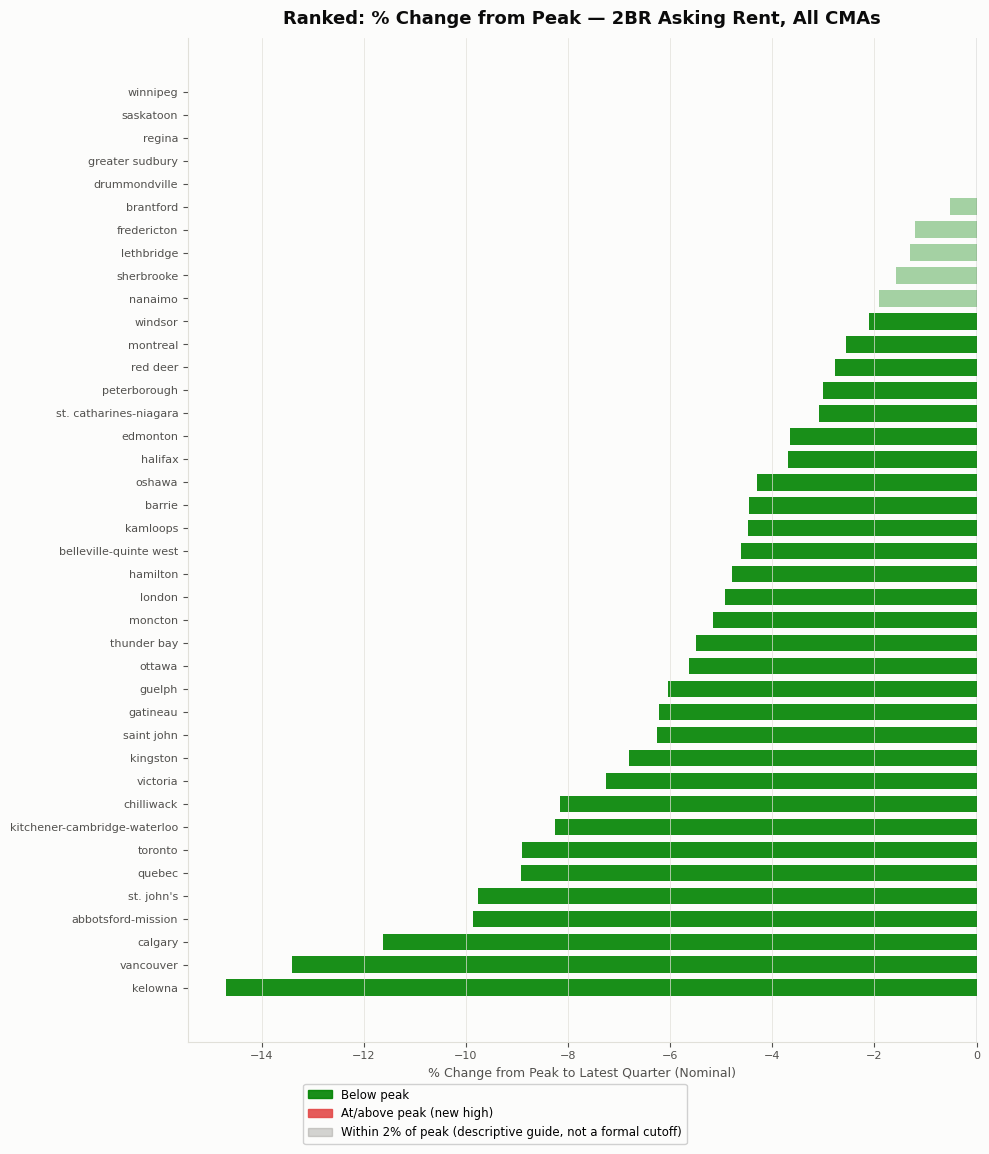

In [13]:
plot_df = valid.sort_values('decline_peak_to_latest_pct')

fig, ax = plt.subplots(figsize=(10, 11))
colors = [C4 if v < 0 else C6 for v in plot_df['decline_peak_to_latest_pct']]
alphas = [0.90 if abs(v) >= DESCRIPTIVE_THRESHOLDS[0] else 0.35 for v in plot_df['decline_peak_to_latest_pct']]
for i, (v, c, a) in enumerate(zip(plot_df['decline_peak_to_latest_pct'], colors, alphas)):
    ax.barh(i, v, color=c, alpha=a, edgecolor='none', height=0.72)
ax.axvline(0, color=INK2, linewidth=0.9, zorder=3)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=8)
ax.set_xlabel('% Change from Peak to Latest Quarter (Nominal)', fontsize=9)
ax.set_title('Ranked: % Change from Peak — 2BR Asking Rent, All CMAs', fontsize=13,
             fontweight='bold', color=INK, pad=10)
ax.grid(axis='x')
ax.tick_params(labelsize=8)

below_p = mpatches.Patch(color=C4, alpha=0.9, label='Below peak')
above_p = mpatches.Patch(color=C6, alpha=0.9, label='At/above peak (new high)')
faded_p = mpatches.Patch(color=MUTED, alpha=0.35, label=f'Within {DESCRIPTIVE_THRESHOLDS[0]:.0f}% of peak (descriptive guide, not a formal cutoff)')
fig.legend(handles=[below_p, above_p, faded_p], loc='lower center', ncol=1,
           fontsize=8.5, framealpha=0.9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

The ±2% shading is a **descriptive guide** distinguishing likely noise from
a clearer signal — not a formal statistical cutoff. Most CMAs sit in the
"below peak, but not dramatically" zone rather than at either extreme.

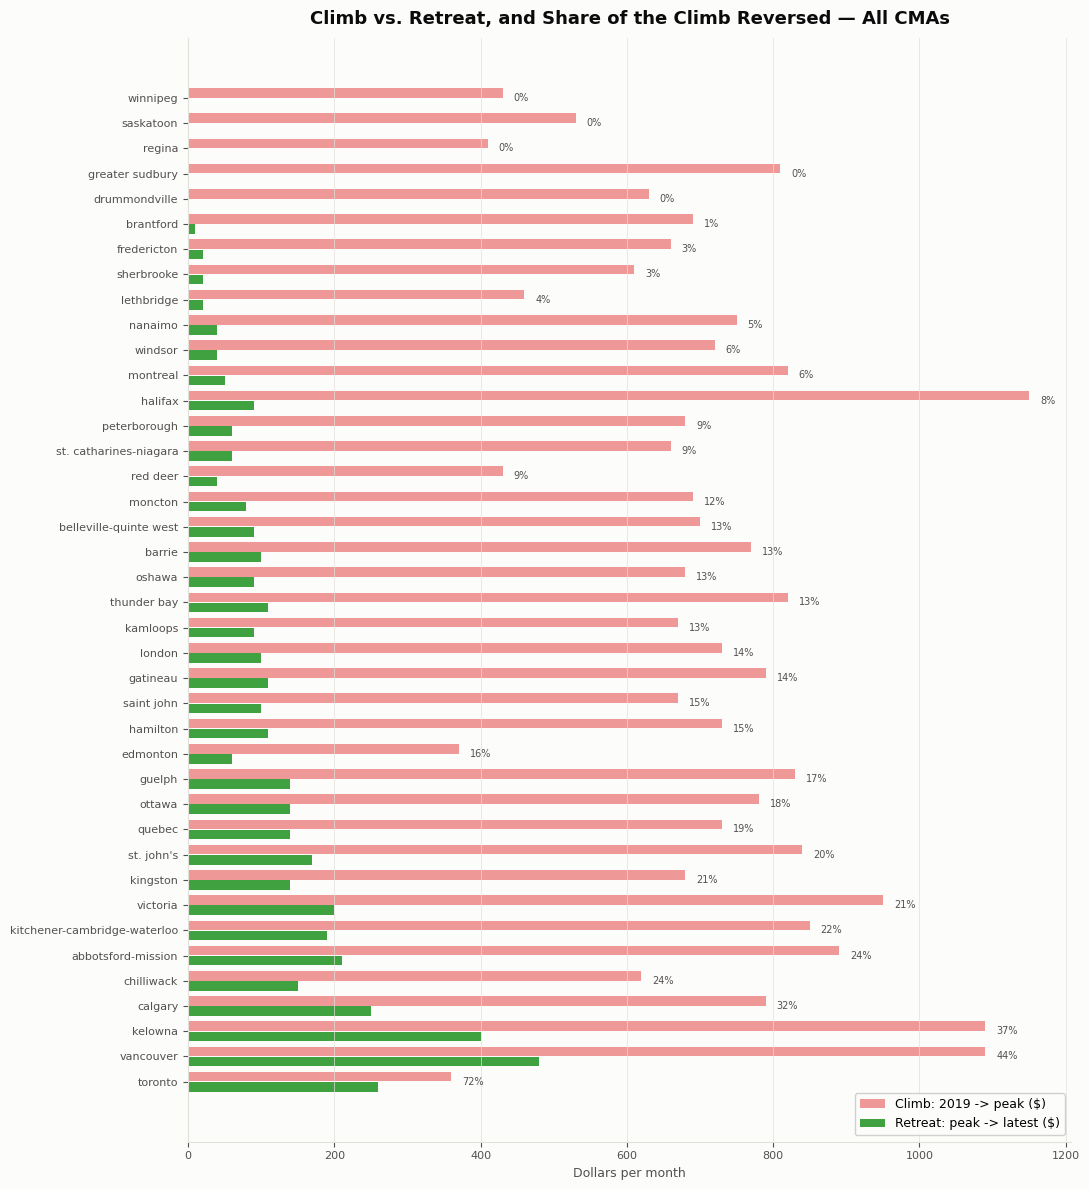

In [14]:
climb_retreat = valid.sort_values('share_reversed', ascending=False)

fig, ax = plt.subplots(figsize=(11, 12))
y = np.arange(len(climb_retreat))

ax.barh(y, climb_retreat['increase_2019_to_peak_d'], color=C6, alpha=0.55, height=0.38,
        label='Climb: 2019 -> peak ($)')
ax.barh(y - 0.40, -climb_retreat['decline_peak_to_latest_d'].clip(upper=0), color=C4, alpha=0.75,
        height=0.38, label='Retreat: peak -> latest ($)')

ax.set_yticks(y - 0.20)
ax.set_yticklabels(climb_retreat.index, fontsize=7.8)
ax.set_xlabel('Dollars per month', fontsize=9)
ax.set_title('Climb vs. Retreat, and Share of the Climb Reversed — All CMAs', fontsize=13,
             fontweight='bold', color=INK, pad=10)
ax.grid(axis='x')
ax.tick_params(labelsize=8)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

for yi, (city, row) in zip(y, climb_retreat.iterrows()):
    ax.annotate(f'{row["share_reversed"]:.0f}%', (row['increase_2019_to_peak_d'] + 15, yi - 0.20),
                fontsize=7, color=INK2, va='center')

plt.tight_layout()
plt.show()

This is the story-relevant chart: the dollar size of each city's 2019 →
peak climb (top bar) against the dollar size of its peak → latest retreat
(bottom bar), with the share-reversed percentage annotated. It makes the
scale mismatch visible directly, rather than requiring the reader to compare
two percentages with different denominators.

**Rough descriptive groups** (using the same non-formal thresholds as
Section 4):

In [15]:
def bucket(row):
    if row['decline_peak_to_latest_pct'] >= 0:
        return 'At/above peak (new high)'
    if row['share_reversed'] >= 50:
        return 'Substantial correction (>=50% of climb reversed)'
    if row['share_reversed'] >= 15:
        return 'Moderate correction (15-50% reversed)'
    return 'Small correction (<15% reversed) / near peak'

valid['descriptive_group'] = valid.apply(bucket, axis=1)
group_order = ['At/above peak (new high)', 'Substantial correction (>=50% of climb reversed)',
               'Moderate correction (15-50% reversed)', 'Small correction (<15% reversed) / near peak']
counts = valid['descriptive_group'].value_counts().reindex(group_order, fill_value=0)
for g, n in counts.items():
    print(f'  {g}: {n} CMAs')

  At/above peak (new high): 5 CMAs
  Substantial correction (>=50% of climb reversed): 1 CMAs
  Moderate correction (15-50% reversed): 14 CMAs
  Small correction (<15% reversed) / near peak: 20 CMAs


### City Small Multiples (Featured Cities)

A curated subset — the largest markets plus a spread of correction sizes —
each showing the 2019 starting value, the nominal peak, and the latest
observation. The full 40-city grid is in Section 11 (Supplementary); it
doesn't add a materially different finding over this smaller set, so it's
kept out of the main narrative.

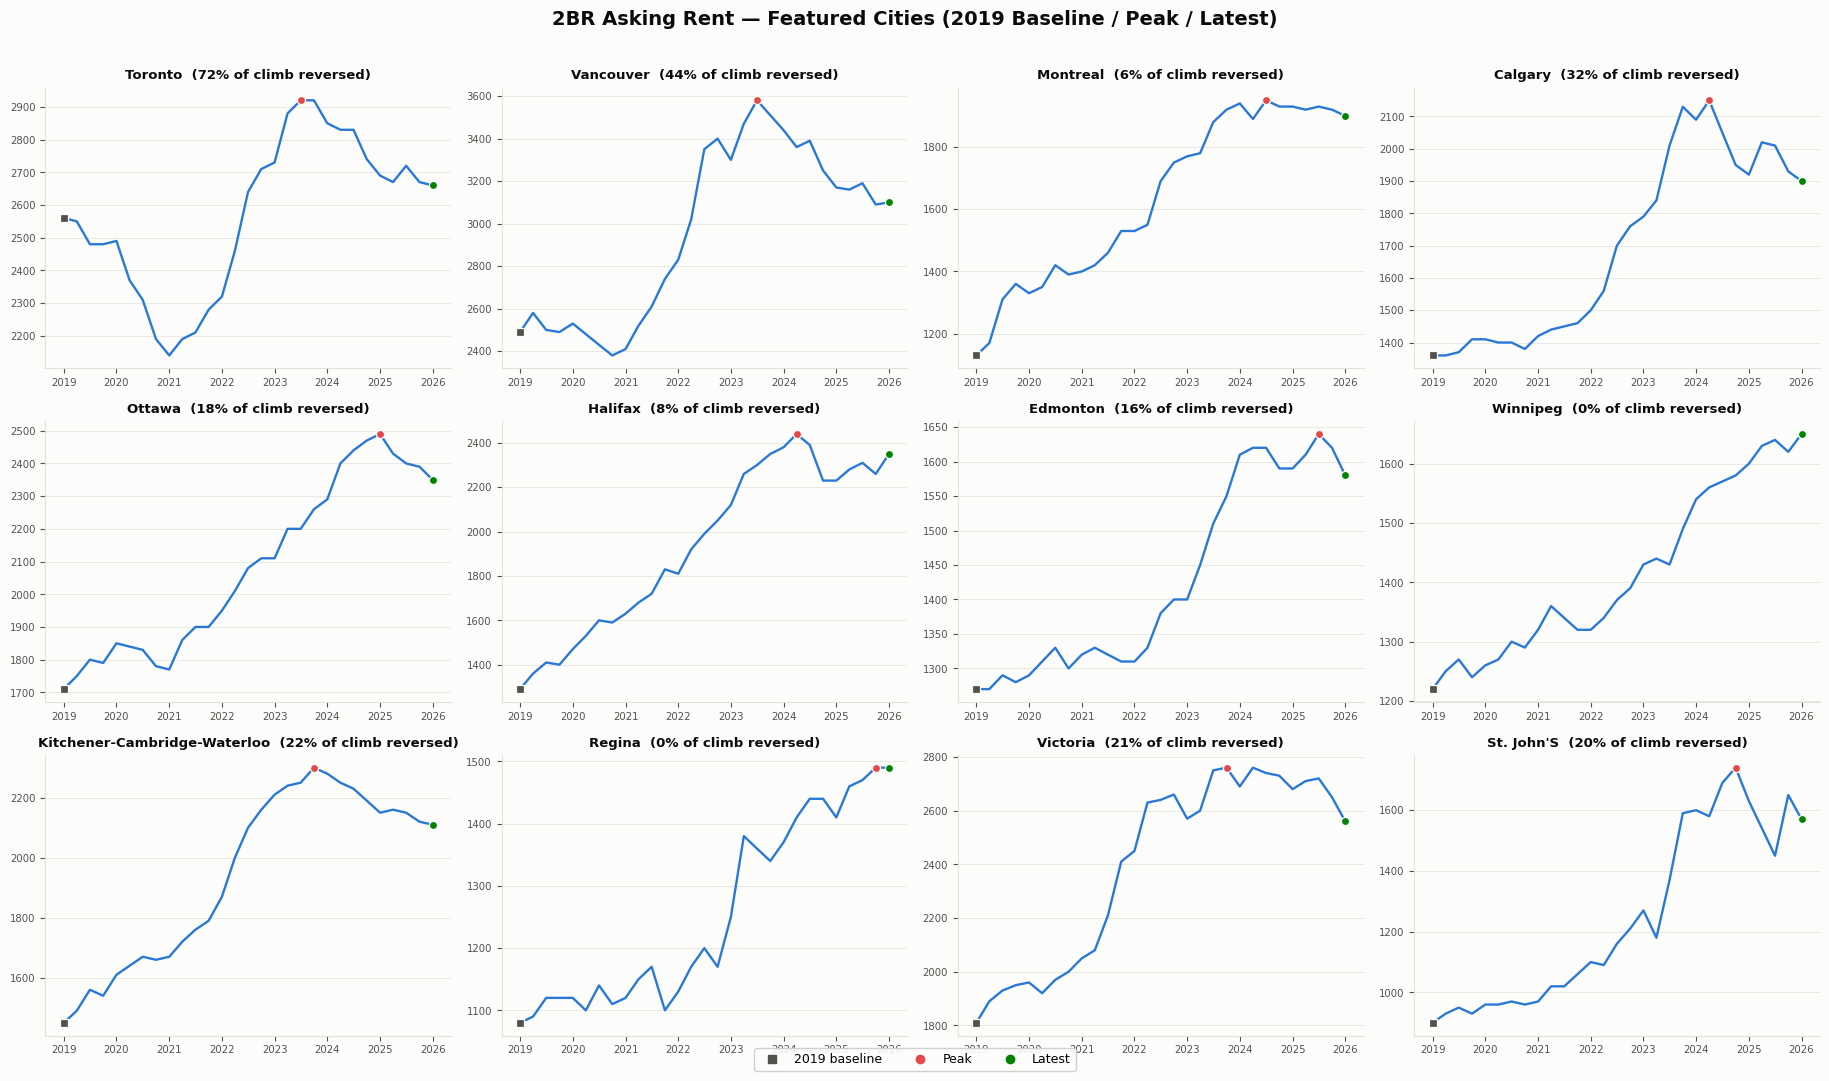

In [16]:
featured = [c for c in FEATURED_CITIES if c in asking]

def plot_small_multiples(city_list, ncols=4, figsize_scale=(4.6, 3.5), suptitle=''):
    n_rows = -(-len(city_list) // ncols)
    fig, axes = plt.subplots(n_rows, ncols, figsize=(figsize_scale[0] * ncols, figsize_scale[1] * n_rows),
                              sharex=False)
    axes_flat = np.atleast_1d(axes).flatten()
    for ax, city in zip(axes_flat, city_list):
        series = asking[city]
        x = series.index.to_timestamp()
        st = asking_peak.loc[city]
        ax.plot(x, series.values, color=C1, linewidth=1.7, zorder=4)
        ax.scatter([st['base_period'].to_timestamp()], [st['base_value']], color=INK2, s=30,
                   zorder=6, edgecolors=SURFACE, linewidths=0.9, marker='s')
        ax.scatter([st['peak_period'].to_timestamp()], [st['peak_value']], color=C6, s=34,
                   zorder=6, edgecolors=SURFACE, linewidths=0.9)
        ax.scatter([st['latest_period'].to_timestamp()], [st['latest_value']], color=C4, s=34,
                   zorder=6, edgecolors=SURFACE, linewidths=0.9)
        ax.set_title(f'{city.title()}  ({st["share_reversed"]:.0f}% of climb reversed)',
                     fontsize=9.5, fontweight='bold', color=INK)
        ax.grid(axis='y')
        ax.tick_params(labelsize=7.3)
    for ax in axes_flat[len(city_list):]:
        ax.set_visible(False)
    handles = [plt.Line2D([0], [0], marker='s', color=INK2, linestyle='', label='2019 baseline'),
               plt.Line2D([0], [0], marker='o', color=C6, linestyle='', label='Peak'),
               plt.Line2D([0], [0], marker='o', color=C4, linestyle='', label='Latest')]
    fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9, framealpha=0.9,
               bbox_to_anchor=(0.5, -0.02 / n_rows))
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, fontweight='bold', color=INK, y=1.01)
    plt.tight_layout()
    plt.show()


plot_small_multiples(featured, suptitle='2BR Asking Rent — Featured Cities (2019 Baseline / Peak / Latest)')

## 6 — Alternative Comparison Dates and Robustness Checks

Selecting the maximum observation as "the peak" guarantees, by construction,
that peak-to-latest change cannot be positive — it's a useful descriptive
device, but it can exaggerate the correction if a single unusually high
quarter drove the maximum. This section checks whether the central
conclusions survive under alternative, less noise-sensitive peak
definitions, and separately compares the latest quarter against several
fixed reference dates.

In [17]:
def rolling_avg_peak(series: pd.Series, window=4) -> tuple:
    roll = series.rolling(window, min_periods=window).mean()
    p = roll.idxmax()
    return p, roll[p]


def sustained_peak(series: pd.Series, min_lower_run=2) -> tuple:
    """Latest local peak followed by at least `min_lower_run` consecutive
    strictly-lower quarters (or the raw max if no such point exists)."""
    vals = series.values
    idx = series.index
    for i in range(len(vals) - 1, -1, -1):
        run = 0
        for j in range(i + 1, len(vals)):
            if vals[j] < vals[i]:
                run += 1
                if run >= min_lower_run:
                    return idx[i], vals[i]
            else:
                break
    p = series.idxmax()
    return p, series[p]


def peak_year_avg(series: pd.Series) -> tuple:
    peak_year = series.idxmax().year
    yr_vals = series[series.index.map(lambda p: p.year) == peak_year]
    return pd.Period(f'{peak_year}Q2'), yr_vals.mean()


robustness_rows = []
for city, series in {**asking, 'ALL_CANADA': asking_national}.items():
    latest_v = series.iloc[-1]
    raw_p, raw_v = series.idxmax(), series.max()
    roll_p, roll_v = rolling_avg_peak(series)
    sust_p, sust_v = sustained_peak(series)
    yr_p, yr_v = peak_year_avg(series)
    robustness_rows.append({
        'city': city,
        'raw_max_pct': (latest_v - raw_v) / raw_v * 100,
        'rolling4q_max_pct': (latest_v - roll_v) / roll_v * 100,
        'sustained_peak_pct': (latest_v - sust_v) / sust_v * 100,
        'peak_year_avg_pct': (latest_v - yr_v) / yr_v * 100,
    })
robustness = pd.DataFrame(robustness_rows).set_index('city')

print('Median peak-to-latest % change under four peak definitions (all CMAs + national):')
print('-' * 68)
print(robustness.median().round(2).to_string())
print()
print('Robustness check: does any alternative definition flip the sign of the median,')
print('or change it by more than a couple of points?')
print(robustness.describe().round(2).loc[['mean', 'std', 'min', 'max']].to_string())

Median peak-to-latest % change under four peak definitions (all CMAs + national):
--------------------------------------------------------------------
raw_max_pct          -4.48
rolling4q_max_pct    -2.27
sustained_peak_pct   -2.02
peak_year_avg_pct    -1.54

Robustness check: does any alternative definition flip the sign of the median,
or change it by more than a couple of points?
      raw_max_pct  rolling4q_max_pct  sustained_peak_pct  peak_year_avg_pct
mean        -4.92              -3.05               -0.93              -2.15
std          3.69               3.58                7.54               3.64
min        -14.71             -11.43               -9.77             -10.53
max          0.00               3.33               33.61               7.53


**Reading this table:** if the median percentage change is similar in sign
and rough magnitude across all four peak definitions, the "modest
correction" conclusion is not an artifact of picking the single highest
quarter. If one definition (typically the raw quarterly max, which is the
most exposed to a one-quarter spike) diverges sharply from the smoother
rolling-average or peak-year-average definitions, that's a sign the raw-max
figure is inflating the apparent correction for at least some cities — worth
flagging explicitly rather than silently preferring whichever definition
looks most dramatic.

In [18]:
national_row = robustness.loc['ALL_CANADA']
print('National peak-to-latest % change by definition:')
for col in ['raw_max_pct', 'rolling4q_max_pct', 'sustained_peak_pct', 'peak_year_avg_pct']:
    print(f'  {col:22s}: {national_row[col]:+.2f}%')

National peak-to-latest % change by definition:
  raw_max_pct           : -4.44%
  rolling4q_max_pct     : -4.12%
  sustained_peak_pct    : -3.15%
  peak_year_avg_pct     : -0.69%


### Fixed-date comparisons

Rather than always benchmarking against a self-selected peak, this compares
the latest quarter against four fixed reference points: Q1 2019, one year
ago, two years ago, and the (raw) peak.

In [19]:
def fixed_date_compare(series: pd.Series) -> dict:
    latest_p = series.index.max()
    latest_v = series[latest_p]
    out = {'latest_period': latest_p, 'latest_value': latest_v}
    for label, target in [('vs_2019', BASELINE_QUARTER),
                           ('vs_1yr_ago', latest_p - 4),
                           ('vs_2yr_ago', latest_p - 8)]:
        if target in series.index:
            out[f'{label}_pct'] = (latest_v - series[target]) / series[target] * 100
        else:
            out[f'{label}_pct'] = np.nan
    peak_p = series.idxmax()
    out['vs_peak_pct'] = (latest_v - series[peak_p]) / series[peak_p] * 100
    return out


fixed_rows = []
for city, series in asking.items():
    d = fixed_date_compare(series)
    d['city'] = city
    fixed_rows.append(d)
fixed_compare = pd.DataFrame(fixed_rows).set_index('city')

national_fixed = fixed_date_compare(asking_national)
print('National, latest quarter vs. fixed reference points:')
for k in ['vs_2019_pct', 'vs_1yr_ago_pct', 'vs_2yr_ago_pct', 'vs_peak_pct']:
    print(f'  {k:16s}: {national_fixed[k]:+.1f}%')
print()
fixed_compare[['vs_2019_pct', 'vs_1yr_ago_pct', 'vs_2yr_ago_pct', 'vs_peak_pct']].round(1)

National, latest quarter vs. fixed reference points:
  vs_2019_pct     : +41.4%
  vs_1yr_ago_pct  : -0.9%
  vs_2yr_ago_pct  : -4.0%
  vs_peak_pct     : -4.4%



,vs_2019_pct,vs_1yr_ago_pct,vs_2yr_ago_pct,vs_peak_pct
city,,,,
abbotsford-mission,54.8,-5.0,-5.9,-9.9
barrie,45.6,0.9,-4.5,-4.5
belleville-quinte west,48.8,0.0,1.6,-4.6
brantford,54.0,3.2,1.6,-0.5
calgary,39.7,-1.0,-9.1,-11.6
chilliwack,38.5,-1.2,-8.2,-8.2
drummondville,105.0,2.5,11.8,0.0
edmonton,24.4,-0.6,-1.9,-3.7
fredericton,63.4,5.1,5.8,-1.2


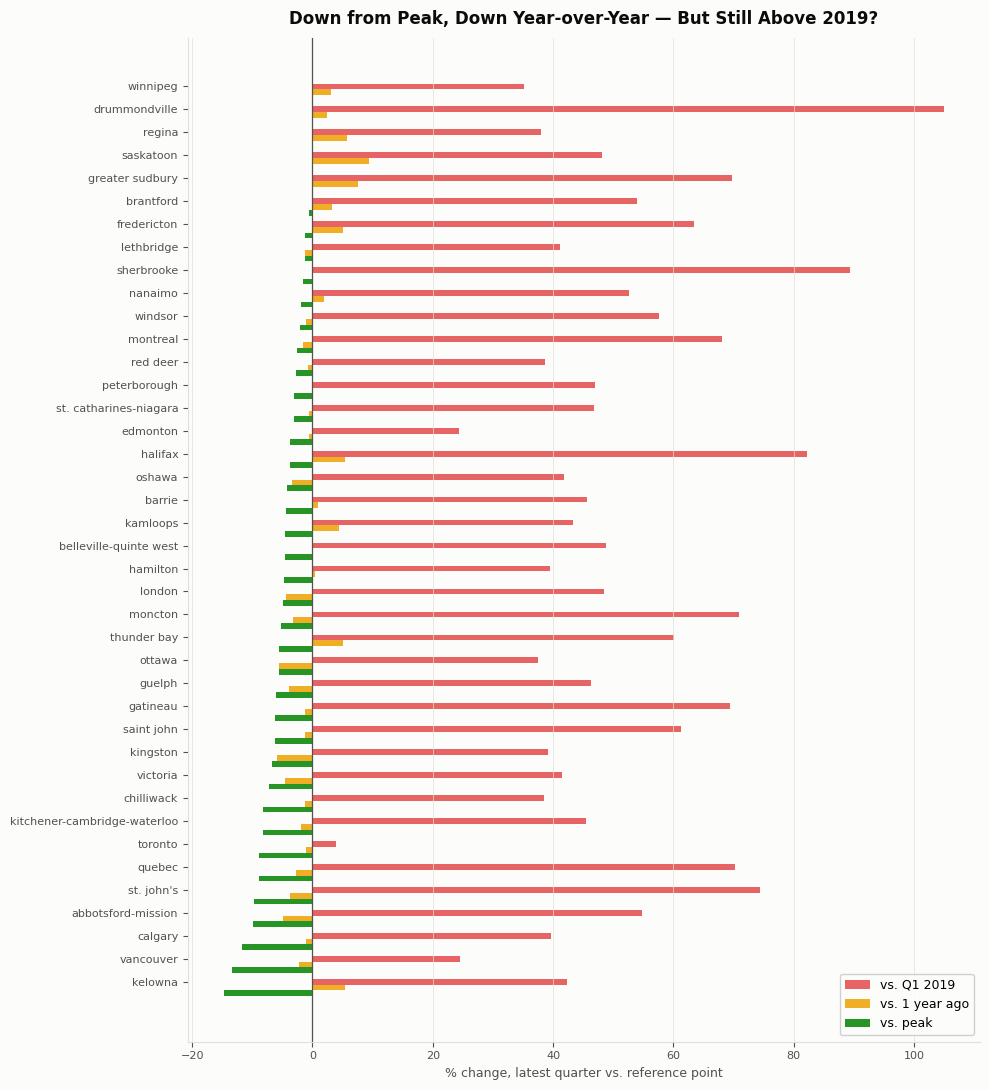

23/40 CMAs are simultaneously down from peak, down year-over-year,
AND still above their Q1 2019 level — the pattern the chart is designed to surface:
a real change in direction that has not restored earlier rent levels.


In [20]:
# ── Concise chart: down from peak, down YoY, but still above 2019 ────────
order = fixed_compare['vs_peak_pct'].sort_values().index
plot_cols = ['vs_2019_pct', 'vs_1yr_ago_pct', 'vs_peak_pct']
plot_labels = ['vs. Q1 2019', 'vs. 1 year ago', 'vs. peak']
plot_colors = [C6, C3, C4]

fig, ax = plt.subplots(figsize=(10, 11))
y = np.arange(len(order))
bar_h = 0.25
for i, (col, label, color) in enumerate(zip(plot_cols, plot_labels, plot_colors)):
    ax.barh(y + (1 - i) * bar_h, fixed_compare.loc[order, col], height=bar_h,
            color=color, alpha=0.85, label=label)
ax.axvline(0, color=INK2, linewidth=0.9)
ax.set_yticks(y + bar_h)
ax.set_yticklabels(order, fontsize=7.8)
ax.set_xlabel('% change, latest quarter vs. reference point', fontsize=9)
ax.set_title('Down from Peak, Down Year-over-Year — But Still Above 2019?', fontsize=12,
             fontweight='bold', color=INK, pad=10)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(axis='x')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

n_all_three = int(((fixed_compare['vs_peak_pct'] < 0) & (fixed_compare['vs_1yr_ago_pct'] < 0) &
                    (fixed_compare['vs_2019_pct'] > 0)).sum())
print(f'{n_all_three}/{len(fixed_compare)} CMAs are simultaneously down from peak, down year-over-year,')
print('AND still above their Q1 2019 level — the pattern the chart is designed to surface:')
print('a real change in direction that has not restored earlier rent levels.')

## 7 — Inflation-Adjusted Results

Nominal dollars are the main public-facing story throughout this notebook.
This section repeats the core national and cross-city measures in constant
dollars as a robustness/interpretation check. **Real-rent change measures
rent relative to general consumer prices — it does not directly measure
affordability relative to renter income** (see Section 10 for why an
income-based affordability measure isn't included here).

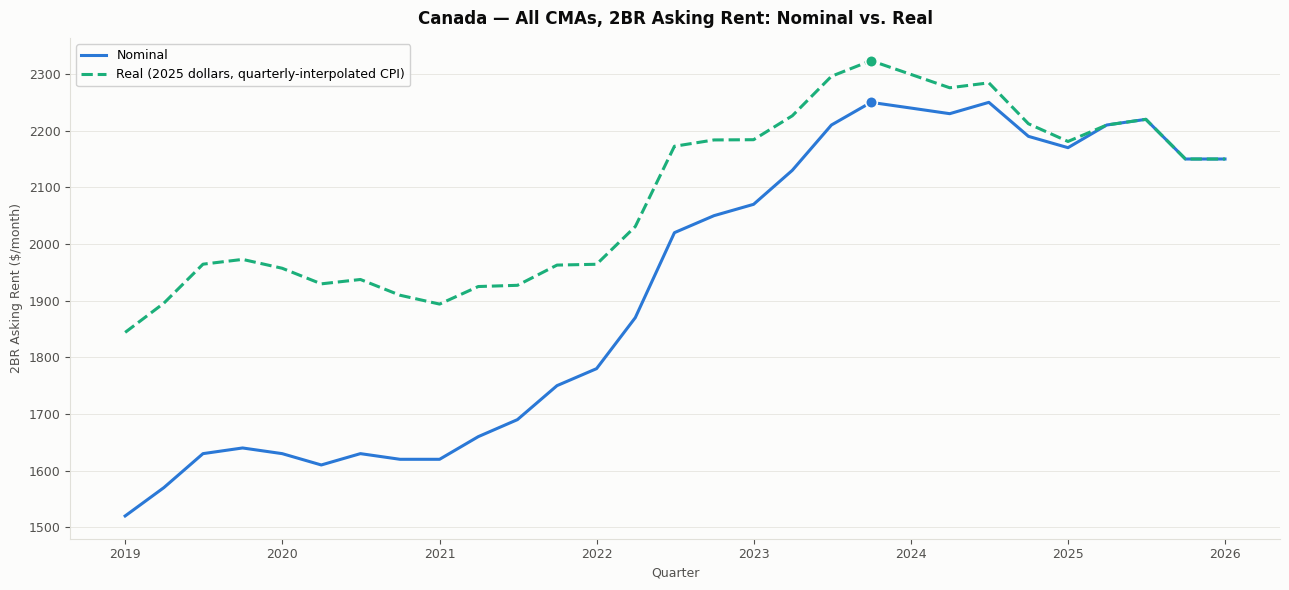

National share of the 2019->peak increase reversed:
  Nominal: 13.7%
  Real:    36.2%


In [21]:
real_national = deflate_quarterly(asking_national, CPI_CANADA_Q)
national_real = peak_stats(real_national, BASELINE_QUARTER)

x = asking_national.index.to_timestamp()
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(x, asking_national.values, color=C1, linewidth=2.2, label='Nominal')
ax.plot(x, real_national.values, color=C2, linewidth=2.2, linestyle='--',
        label=f'Real ({CPI_CANADA_Q.index.max().year} dollars, quarterly-interpolated CPI)')

for stats_d, color in [(national_nom, C1), (national_real, C2)]:
    px = stats_d['peak_period'].to_timestamp()
    ax.scatter([px], [stats_d['peak_value']], color=color, s=70, zorder=6,
               edgecolors=SURFACE, linewidths=1.2)

ax.set_ylabel('2BR Asking Rent ($/month)', fontsize=9)
ax.set_xlabel('Quarter', fontsize=9)
ax.set_title('Canada — All CMAs, 2BR Asking Rent: Nominal vs. Real', fontsize=12,
             fontweight='bold', color=INK, pad=10)
ax.legend(loc='upper left', fontsize=9, framealpha=0.88)
ax.grid(axis='y')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

print(f'National share of the 2019->peak increase reversed:')
print(f'  Nominal: {national_nom["share_reversed"]:.1f}%')
print(f'  Real:    {national_real["share_reversed"]:.1f}%')

In [22]:
real_rows = []
for city, series in asking.items():
    real = deflate_quarterly(series, city_cpi_q(city))
    st = peak_stats(real, BASELINE_QUARTER)
    st['city'] = city
    real_rows.append(st)
asking_peak_real = pd.DataFrame(real_rows).set_index('city')

valid_real = asking_peak_real[asking_peak_real['increase_2019_to_peak_d'] > 0]
common_valid = sorted(set(valid.index) & set(valid_real.index))
no_real_runup = sorted(set(valid.index) - set(valid_real.index))
compare = pd.DataFrame({
    'share_reversed_nominal': valid.loc[common_valid, 'share_reversed'],
    'share_reversed_real': valid_real.loc[common_valid, 'share_reversed'],
})
compare['gap'] = compare['share_reversed_real'] - compare['share_reversed_nominal']

if no_real_runup:
    print(f'{len(no_real_runup)} CMA(s) had no real (inflation-adjusted) increase from 2019 to their')
    print(f'nominal peak at all -- rent growth there never outpaced inflation over that window, so')
    print(f'"share reversed in real terms" is undefined for them: {no_real_runup}')
    print()

print(f'Share of the climb reversed — nominal vs. real, {len(compare)} CMAs')
print('-' * 68)
print(f'  Median, nominal: {compare["share_reversed_nominal"].median():.1f}%')
print(f'  Median, real:    {compare["share_reversed_real"].median():.1f}%')
print(f'  Median gap (real - nominal): {compare["gap"].median():+.1f} pp')
print()
print('Interpretation: inflation adjustment moves the correction, but does not by')
print('itself establish restored affordability relative to renter income (Section 10).')

1 CMA(s) had no real (inflation-adjusted) increase from 2019 to their
nominal peak at all -- rent growth there never outpaced inflation over that window, so
"share reversed in real terms" is undefined for them: ['toronto']

Share of the climb reversed — nominal vs. real, 39 CMAs
--------------------------------------------------------------------
  Median, nominal: 13.2%
  Median, real:    25.6%
  Median gap (real - nominal): +11.7 pp

Interpretation: inflation adjustment moves the correction, but does not by
itself establish restored affordability relative to renter income (Section 10).


## 8 — Comparison with CMHC Occupied-Rent Data

CMHC's average-rent series is a **complementary perspective, not a
validation test**, of the StatCan asking-rent correction. The two measure
meaningfully different things:

| | StatCan asking rents | CMHC average rent |
|---|---|---|
| Population | Newly advertised units | All occupied units in the primary purpose-built stock |
| Frequency | Quarterly | Annual |
| Bedroom type | 2-bedroom only | All unit types combined (no CMA-level 2BR breakout in this dataset) |
| What it captures | Market-entry price today | Blended rent across long-tenured and newly-turned-over units |

Two series this dataset does provide beyond average rent: **vacancy rate**
and **median rent**. Turnover-only and non-turnover-only rent series (which
would isolate CMHC's newly re-let units — the closest CMHC analogue to an
asking rent) are **not available** in this repo's CMHC extract, so they are
not used here.

Because asking rents are a leading indicator, it is expected that a
correction shows up there before it appears in the broader, slower-moving
occupied-rent measure — a disagreement between the two sources is not
evidence that either one is wrong.

In [23]:
cmhc_rows = []
for city, df in cmhc.items():
    series = df['Average Rent'].dropna()
    st = peak_stats(series)
    st['city'] = city
    st['latest_vacancy'] = df['Vacancy Rate'].dropna().iloc[-1] if df['Vacancy Rate'].notna().any() else np.nan
    cmhc_rows.append(st)
cmhc_peak = pd.DataFrame(cmhc_rows).set_index('city')

n_at_peak = int((cmhc_peak['decline_peak_to_latest_pct'] == 0).sum())
print(f'{n_at_peak}/{len(cmhc_peak)} CMAs have their all-time-high CMHC average rent in the latest')
print(f'available year ({cmhc_peak["peak_period"].max()}) — by this slower, whole-market measure,')
print(f'{len(cmhc_peak) - n_at_peak} of these cities have registered any decline from their own historical peak.')
print()
print(f'Median latest-year CMHC vacancy rate: {cmhc_peak["latest_vacancy"].median():.2f}%')

40/40 CMAs have their all-time-high CMHC average rent in the latest
available year (2025) — by this slower, whole-market measure,
0 of these cities have registered any decline from their own historical peak.

Median latest-year CMHC vacancy rate: 3.05%


In [24]:
# ── Exploratory city-level comparison: asking-rent correction vs. latest CMHC
# YoY growth. Reported as effect size (correlation, with a bootstrap CI), not
# as a significance test, per the reframing in this section's intro.
cmhc_latest_yoy = {}
for city, df in cmhc.items():
    series = df['Average Rent'].dropna()
    yoy = series.pct_change().dropna() * 100
    if len(yoy):
        cmhc_latest_yoy[city] = yoy.iloc[-1]

corr_cities = sorted(set(asking_peak.index) & set(cmhc_latest_yoy))
paired = pd.DataFrame({
    'asking_pct_from_peak': asking_peak.loc[corr_cities, 'decline_peak_to_latest_pct'],
    'cmhc_latest_yoy_pct': pd.Series(cmhc_latest_yoy).loc[corr_cities],
})

r_s, _ = stats.spearmanr(paired['asking_pct_from_peak'], paired['cmhc_latest_yoy_pct'])

rng = np.random.default_rng(BOOTSTRAP_SEED)
boot_r = []
n_pair = len(paired)
for _ in range(BOOTSTRAP_N):
    idx = rng.integers(0, n_pair, n_pair)
    boot_r.append(stats.spearmanr(paired['asking_pct_from_peak'].values[idx],
                                   paired['cmhc_latest_yoy_pct'].values[idx])[0])
r_lo, r_hi = np.percentile(boot_r, [2.5, 97.5])

print(f'Exploratory city-level association, {n_pair} CMAs')
print('-' * 68)
print('  x = asking-rent % change from peak (more negative = bigger correction)')
print('  y = latest-year CMHC average-rent YoY growth')
print(f'  Spearman rho = {r_s:+.2f}   bootstrap 95% CI [{r_lo:+.2f}, {r_hi:+.2f}]')
print()
print('  Treat this as a rough effect-size summary, not a confirmatory test: CMAs are not')
print('  independent of each other, and CMHC average rent moves too slowly to be a fair')
print('  same-period benchmark for a quarterly asking-rent leading indicator.')

Exploratory city-level association, 38 CMAs
--------------------------------------------------------------------
  x = asking-rent % change from peak (more negative = bigger correction)
  y = latest-year CMHC average-rent YoY growth
  Spearman rho = +0.23   bootstrap 95% CI [-0.13, +0.55]

  Treat this as a rough effect-size summary, not a confirmatory test: CMAs are not
  independent of each other, and CMHC average rent moves too slowly to be a fair
  same-period benchmark for a quarterly asking-rent leading indicator.


**How to read this section:** CMHC data continuing to show high or rising
occupied rents does not contradict the asking-rent correction — it reflects
a broader, slower-moving population of renters (mostly in-place tenants
whose rent adjusts on a lease-renewal schedule, not a listing-by-listing
basis). Asking rents can and typically do turn before the occupied-stock
average follows.

## 9 — Historical Context

**Narrow question for this section: how unusual are nominal declines in
occupied purpose-built rents historically?** This uses CMHC's much longer
annual history (back to 1990 for most CMAs) — a different measure, on a
different frequency, from the current quarterly asking-rent correction, so
the two are not treated as directly equivalent.

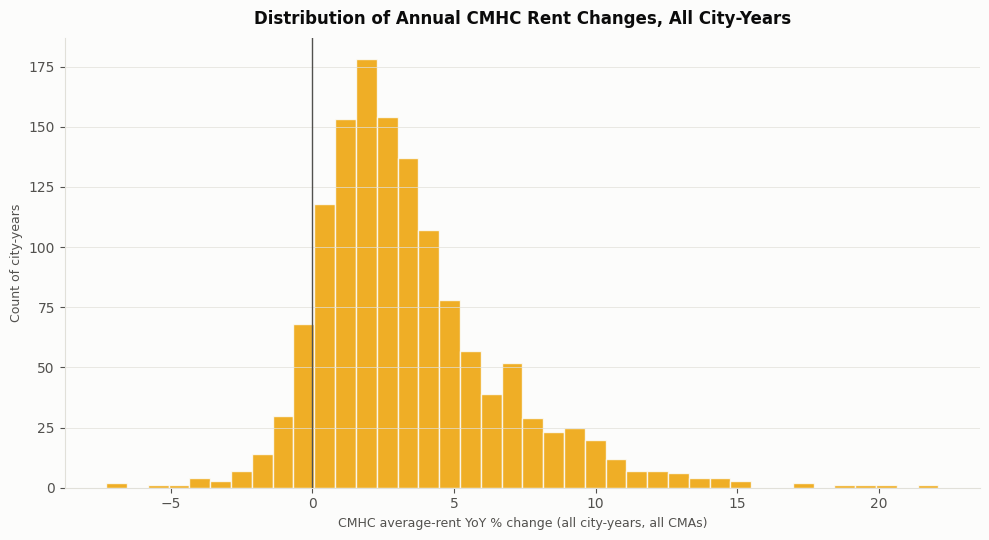

112/1349 city-years (8.3%) show a nominal decline.

Share of city-years with a nominal decline, by decade:
decade
1990    16.9
2000     7.0
2010     6.5
2020     1.7


In [25]:
all_yoy = []
for city, df in cmhc.items():
    yoy = df['Average Rent'].dropna().pct_change().dropna() * 100
    for yr, v in yoy.items():
        all_yoy.append({'city': city, 'year': yr, 'yoy_pct': v})
all_yoy = pd.DataFrame(all_yoy)
all_yoy['decade'] = (all_yoy['year'] // 10) * 10

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(all_yoy['yoy_pct'], bins=40, color=C3, alpha=0.85, edgecolor=SURFACE)
ax.axvline(0, color=INK2, linewidth=1.0)
ax.set_xlabel('CMHC average-rent YoY % change (all city-years, all CMAs)', fontsize=9)
ax.set_ylabel('Count of city-years', fontsize=9)
ax.set_title('Distribution of Annual CMHC Rent Changes, All City-Years', fontsize=12,
             fontweight='bold', color=INK, pad=10)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

n_decline = int((all_yoy['yoy_pct'] < 0).sum())
print(f'{n_decline}/{len(all_yoy)} city-years ({100*n_decline/len(all_yoy):.1f}%) show a nominal decline.')
print()
by_decade = all_yoy.groupby('decade')['yoy_pct'].apply(lambda s: (s < 0).mean() * 100).round(1)
print('Share of city-years with a nominal decline, by decade:')
print(by_decade.to_string())

In [26]:
down_year_summary = []
for city, df in cmhc.items():
    series = df['Average Rent'].dropna()
    yoy_nom = series.pct_change() * 100
    down_years = yoy_nom[yoy_nom < 0]
    down_year_summary.append({
        'city': city, 'n_years': len(series), 'n_down_years': len(down_years),
        'pct_down_years': 100 * len(down_years) / len(series),
    })
down_year_df = pd.DataFrame(down_year_summary).set_index('city').sort_values('n_down_years', ascending=False)
down_year_df.round(1).head(10)

,n_years,n_down_years,pct_down_years
city,,,
calgary,36,8,22.2
edmonton,36,7,19.4
chilliwack,35,6,17.1
gatineau,36,6,16.7
red deer,36,6,16.7
trois-rivieres,36,5,13.9
barrie,36,5,13.9
greater sudbury,36,4,11.1
saguenay,36,4,11.1


### When did each city's asking-rent peak occur?

Descriptive only — a uniform distribution of peak dates across 2019–2026 is
not a meaningful null for a generally-rising rent series, so no test against
uniformity is reported (see Section 11 for why formal tests here would be
misleading).

In [27]:
peak_years = asking_peak['peak_period'].map(lambda p: p.year)
year_counts = peak_years.value_counts().sort_index()
national_peak_year = national_nom['peak_period'].year

print(f'Number of CMAs peaking in each year (national peak: {national_nom["peak_period"]}):')
print(year_counts.rename('n_cmas').to_string())
print()
print(f'Median peak quarter across CMAs: {asking_peak["peak_period"].map(lambda p: p.ordinal).median():.0f} '
      f'(ordinal); most common year: {year_counts.idxmax()}')
qsp = asking_peak['peak_period'].map(lambda p: abs(p.ordinal - national_nom['peak_period'].ordinal))
n_near_national = int((qsp <= 2).sum())
print(f'{n_near_national}/{len(asking_peak)} CMAs ({100*n_near_national/len(asking_peak):.0f}%) peaked within '
      f'2 quarters of the national peak ({national_nom["peak_period"]}) — a common, largely '
      f'synchronized turning point, alongside some cities with clearly earlier or later local cycles.')

Number of CMAs peaking in each year (national peak: 2023Q4):
peak_period
2022     1
2023     8
2024    19
2025     9
2026     3

Median peak quarter across CMAs: 218 (ordinal); most common year: 2024
15/40 CMAs (38%) peaked within 2 quarters of the national peak (2023Q4) — a common, largely synchronized turning point, alongside some cities with clearly earlier or later local cycles.


In [28]:
early_peakers = asking_peak[asking_peak['peak_period'].map(lambda p: p.ordinal) <
                             national_nom['peak_period'].ordinal - 2].index.tolist()
late_peakers = asking_peak[asking_peak['peak_period'].map(lambda p: p.ordinal) >
                            national_nom['peak_period'].ordinal + 2].index.tolist()
print(f'Cities that peaked notably earlier than the national peak: {early_peakers}')
print(f'Cities that peaked notably later than the national peak:   {late_peakers}')

Cities that peaked notably earlier than the national peak: ['kelowna']
Cities that peaked notably later than the national peak:   ['abbotsford-mission', "st. john's", 'quebec', 'ottawa', 'edmonton', 'hamilton', 'saint john', 'gatineau', 'london', 'thunder bay', 'belleville-quinte west', 'moncton', 'st. catharines-niagara', 'peterborough', 'montreal', 'windsor', 'nanaimo', 'lethbridge', 'fredericton', 'drummondville', 'greater sudbury', 'regina', 'saskatoon', 'winnipeg']


## 10 — Main Findings and Limitations

In [29]:
n_valid = len(valid)
n_below = int((valid['decline_peak_to_latest_pct'] < 0).sum())
print('MAIN FINDINGS')
print('=' * 68)
print(f'1. Asking rents have fallen from recent peaks in most CMAs: '
      f'{n_below}/{n_valid} ({100*n_below/n_valid:.0f}%) are below their own peak.')
print(f'2. The typical decline is small relative to the increase since 2019: median '
      f'share of the 2019->peak dollar increase reversed is {sr.median():.1f}% '
      f'(IQR {sr.quantile(0.25):.0f}-{sr.quantile(0.75):.0f}%).')
print(f'3. Most of the earlier dollar increase remains in place: nationally, '
      f'{national_nom["share_reversed"]:.0f}% of the +${national_nom["increase_2019_to_peak_d"]:.0f} '
      f'climb has come back, leaving +${-national_nom["net_change_d"]:.0f}'
      if national_nom['net_change_d'] < 0 else
      f'3. Most of the earlier dollar increase remains in place: nationally the net change since '
      f'2019 is still {national_nom["net_change_pct"]:+.0f}%')
print(f'4. Inflation adjustment makes the real correction somewhat larger '
      f'({national_real["share_reversed"]:.0f}% vs. {national_nom["share_reversed"]:.0f}% reversed, '
      f'nationally) but does not establish restored affordability.')
print(f'5. CMHC occupied-rent data continue to show high or rising rents: '
      f'{n_at_peak}/{len(cmhc_peak)} CMAs are at their all-time-high CMHC average rent as of the '
      f'latest year available — a broader, slower-moving part of the rental market.')
print('6. "Rents are falling" is factually defensible but incomplete without the size')
print('   and historical baseline of the decline.')

MAIN FINDINGS
1. Asking rents have fallen from recent peaks in most CMAs: 35/40 (88%) are below their own peak.
2. The typical decline is small relative to the increase since 2019: median share of the 2019->peak dollar increase reversed is 13.3% (IQR 6-19%).
3. Most of the earlier dollar increase remains in place: nationally the net change since 2019 is still +41%
4. Inflation adjustment makes the real correction somewhat larger (36% vs. 14% reversed, nationally) but does not establish restored affordability.
5. CMHC occupied-rent data continue to show high or rising rents: 40/40 CMAs are at their all-time-high CMHC average rent as of the latest year available — a broader, slower-moving part of the rental market.
6. "Rents are falling" is factually defensible but incomplete without the size
   and historical baseline of the decline.


### Interpretation

The data support the working expectation stated at the top of this
notebook: the decline in asking rents is **real and geographically
widespread**, but **modest relative to the run-up since 2019** — most of the
earlier dollar increase remains in place, and the broader occupied-rental
market (CMHC) has not yet recorded a comparable turn. This is a neutral
reading of the measures computed above, not an assumption; if a future
update of this data shows the correction accelerating or the CMHC series
turning too, that conclusion should change accordingly.

Nothing here identifies *why* rents have softened (interest rates,
migration policy, new supply, or some combination) — that would require a
separate, causal analysis this notebook does not attempt.

### Limitations

- **Asking rents are listings, not completed leases** — they reflect what
  landlords ask for new units, not necessarily what tenants end up paying.
- **Unit and listing composition may change over time** — a shift in which
  units get listed (e.g. more purpose-built vs. more secondary-market
  listings) could move the series independent of any change in the price of
  a fixed unit.
- **The StatCan series begins only in 2019** — there is no way to check
  whether 2019 itself was already an elevated starting point relative to a
  longer history, the way the CMHC series allows for average rent.
- **Peak selection can magnify temporary variation** — a single unusually
  high quarter can make the subsequent "correction" look larger than the
  underlying trend; Section 6's robustness checks are the mitigation, not a
  complete fix.
- **National and city results can differ substantially** — the national
  aggregate can mask cities running well ahead of or behind the overall
  pattern (Section 5).
- **CMHC and StatCan measure different rental-market populations** at
  different frequencies and, for CMHC, without a 2-bedroom-specific
  breakout or turnover/non-turnover split in this dataset — disagreement
  between them is expected, not a data-quality problem.
- **Inflation adjustment is not equivalent to income affordability.** A
  province-level CPI deflator (quarterly-interpolated from annual data, see
  Section 1) measures rent relative to general consumer prices, not
  relative to what renters actually earn. This notebook does not include a
  rent-to-income measure: the income series available in this repo (median
  total income for economic families and persons not in an economic family)
  does not correspond cleanly to renter-household income for a 2-bedroom
  unit, and it does not yet extend into the window where the asking-rent
  decline shows up. Affordability in the income sense is out of scope here;
  a falling asking rent does not by itself establish that housing has
  become more affordable.
- **CMAs share national economic conditions** (interest rates, immigration
  policy, construction cycles) and are not fully independent replications
  of each other — this is part of why formal significance tests across
  CMAs are demoted to Section 11 rather than treated as the headline
  evidence.
- **This analysis is descriptive.** It documents the size and breadth of
  the correction; it does not identify causes.

## 11 — Supplementary Diagnostics

Secondary statistical tests, full-population small multiples, and other
diagnostic output that would otherwise interrupt the main narrative. These
are retained for transparency and robustness, not as headline evidence —
see Section 10 for why CMA-level significance tests are treated with
caution (shared national conditions mean CMAs are not independent
replications).

### 11.1 — Full city small multiples (all CMAs)

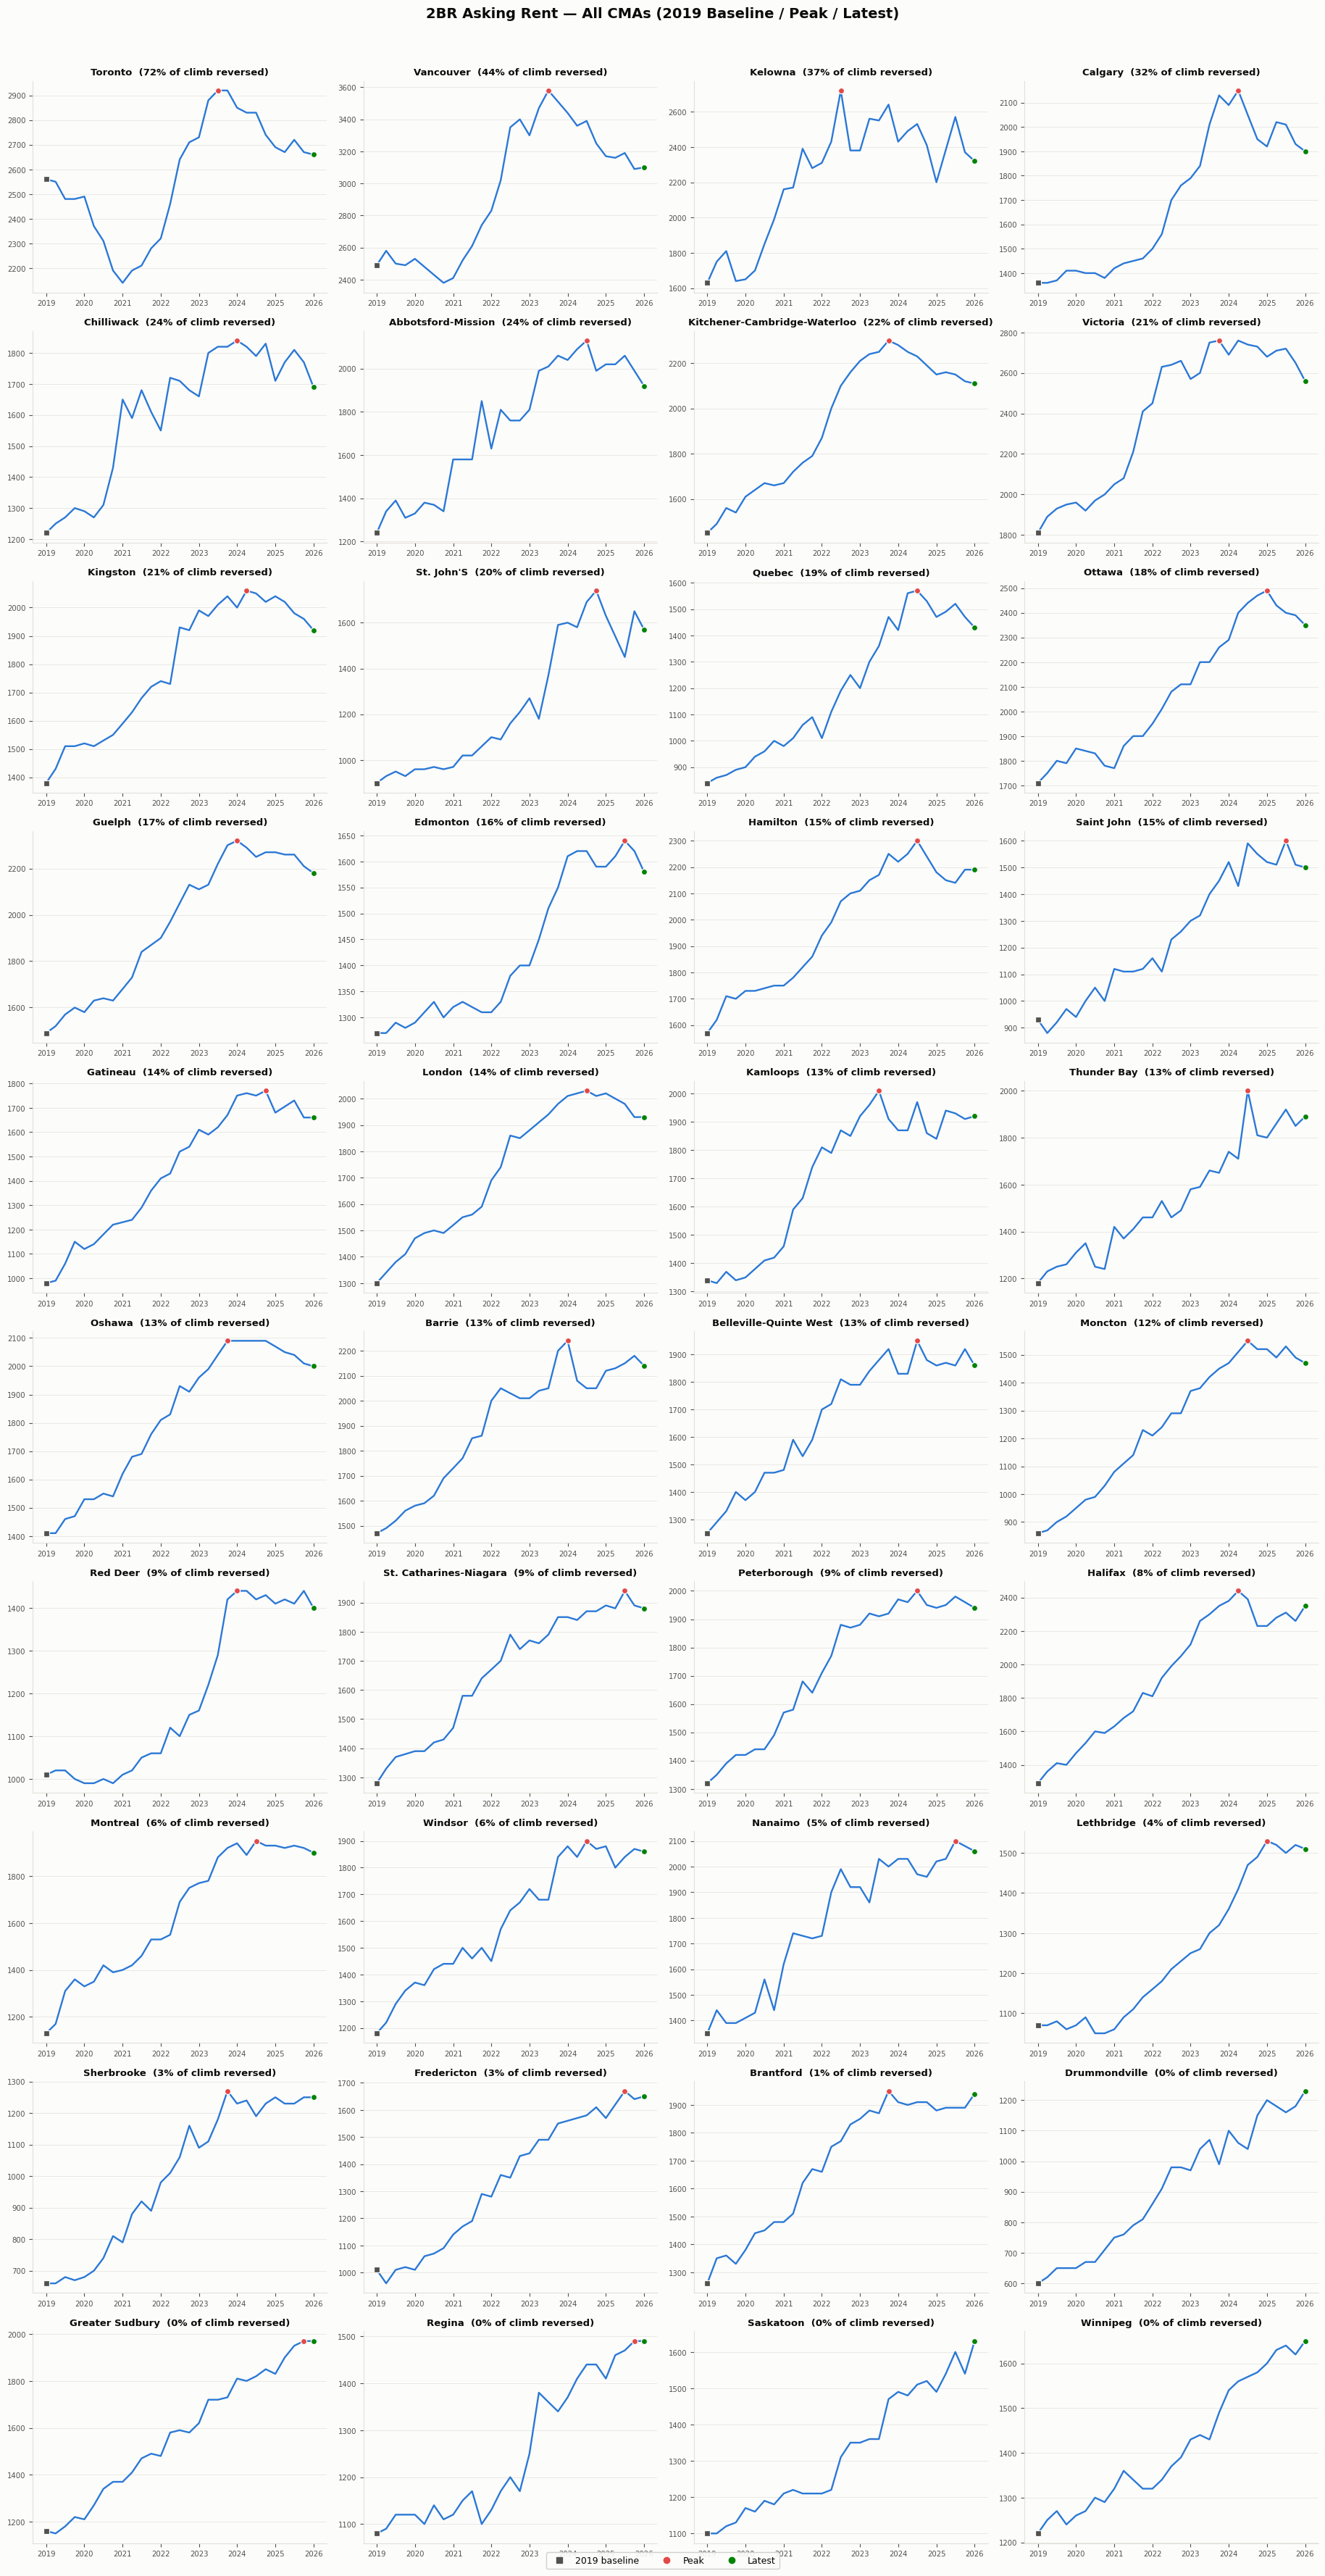

In [30]:
plot_small_multiples(list(asking_peak.index), suptitle='2BR Asking Rent — All CMAs (2019 Baseline / Peak / Latest)')

### 11.2 — CMHC historical small multiples (representative cities)

One volatile market and one comparatively stable market, illustrating the
range of historical CMHC down-year frequency documented in Section 9,
rather than a full 40-city grid.

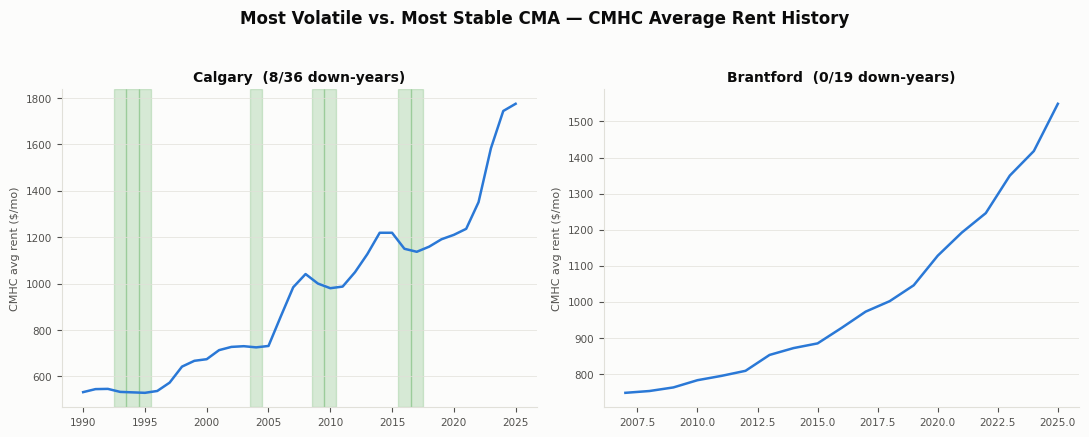

In [31]:
most_volatile = down_year_df.index[0]
most_stable = down_year_df.sort_values('n_down_years').index[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, city in zip(axes, [most_volatile, most_stable]):
    series = cmhc[city]['Average Rent'].dropna()
    yoy_nom = series.pct_change() * 100
    ax.plot(series.index, series.values, color=C1, linewidth=1.8)
    for yr in yoy_nom[yoy_nom < 0].index:
        ax.axvspan(yr - 0.5, yr + 0.5, color=C4, alpha=0.15, zorder=0)
    n_down = int(down_year_df.loc[city, 'n_down_years'])
    n_yrs = int(down_year_df.loc[city, 'n_years'])
    ax.set_title(f'{city.title()}  ({n_down}/{n_yrs} down-years)', fontsize=10, fontweight='bold', color=INK)
    ax.set_ylabel('CMHC avg rent ($/mo)', fontsize=8)
    ax.grid(axis='y')
    ax.tick_params(labelsize=7.5)
fig.suptitle('Most Volatile vs. Most Stable CMA — CMHC Average Rent History', fontsize=12,
             fontweight='bold', color=INK, y=1.03)
plt.tight_layout()
plt.show()

### 11.3 — Demoted inferential tests

These reproduce the earlier version of this notebook's significance tests.
They are retained for transparency but are **not** part of the headline
findings: CMAs are not independent of each other, several of these null
hypotheses (uniform peak-year distribution; a fixed -10% "meaningful
reversal" benchmark; equality of asking-rent and CMHC peak incidence) are
not substantively well-motivated, and the complete distributions reported
in Sections 4–9 already convey what these tests would add.

In [32]:
# One-sample tests against zero (not a headline claim — see note above).
t_stat, t_p = stats.ttest_1samp(valid['decline_peak_to_latest_pct'], 0)
w_stat, w_p = stats.wilcoxon(valid['decline_peak_to_latest_pct'])
print(f'One-sample t-test, pct change from peak vs. 0:  t={t_stat:+.2f}, p={t_p:.4g}')
print(f'Wilcoxon signed-rank, same:                       W={w_stat:.1f}, p={w_p:.4g}')
print()

# Test against a fixed -10% "meaningful reversal" benchmark (arbitrary; not used as evidence).
t10, p10 = stats.ttest_1samp(valid['decline_peak_to_latest_pct'], -10, alternative='greater')
print(f'One-sided t-test vs. an arbitrary -10% benchmark: t={t10:+.2f}, p={p10:.4g}')
print()

# Chi-square vs. a uniform distribution of peak years (uniform is not a meaningful null
# for a generally-rising series — see Section 9).
year_range = range(2019, 2027)
observed = peak_years.value_counts().reindex(year_range, fill_value=0).sort_index()
expected = np.full(len(observed), observed.sum() / len(observed))
chi2_stat, chi2_p = stats.chisquare(observed.values, expected)
print(f'Chi-square goodness-of-fit, peak year vs. uniform: chi2={chi2_stat:.2f}, p={chi2_p:.4g}')

One-sample t-test, pct change from peak vs. 0:  t=-8.35, p=3.293e-10
Wilcoxon signed-rank, same:                       W=0.0, p=2.477e-07

One-sided t-test vs. an arbitrary -10% benchmark: t=+8.57, p=8.444e-11

Chi-square goodness-of-fit, peak year vs. uniform: chi2=63.20, p=3.456e-11


In [33]:
# McNemar-style paired incidence comparison, asking rents vs. CMHC (reproduced from the
# prior version of this notebook for transparency; not used as evidence in Section 8,
# which reframes this as an exploratory effect-size comparison instead).
common_cities = sorted(set(asking_peak.index) & set(cmhc_peak.index))
asking_below = asking_peak.loc[common_cities, 'decline_peak_to_latest_pct'] < 0
cmhc_below = cmhc_peak.loc[common_cities, 'decline_peak_to_latest_pct'] < 0

a = int((asking_below & cmhc_below).sum())
b = int((asking_below & ~cmhc_below).sum())
c = int((~asking_below & cmhc_below).sum())
d = int((~asking_below & ~cmhc_below).sum())
discordant = b + c
print(f'Paired incidence table, {len(common_cities)} common CMAs:')
print(f'  Asking below & CMHC below:        {a}')
print(f'  Asking below & CMHC at/above:      {b}')
print(f'  Asking at/above & CMHC below:      {c}')
print(f'  Asking at/above & CMHC at/above:   {d}')
if discordant:
    mcnemar = stats.binomtest(min(b, c), discordant, 0.5, alternative='two-sided')
    print(f'  McNemar exact test on {discordant} discordant pairs: p={mcnemar.pvalue:.4g}')
    print('  (Reproduced for transparency; Section 8 treats this comparison as')
    print('   exploratory rather than confirmatory — see that section for why.)')

Paired incidence table, 38 common CMAs:
  Asking below & CMHC below:        0
  Asking below & CMHC at/above:      33
  Asking at/above & CMHC below:      0
  Asking at/above & CMHC at/above:   5
  McNemar exact test on 33 discordant pairs: p=2.328e-10
  (Reproduced for transparency; Section 8 treats this comparison as
   exploratory rather than confirmatory — see that section for why.)


### 11.4 — Peak-to-latest summary table (CSV export for downstream use)

In [34]:
export_path = Path('peak_to_latest_summary.csv')
summary_table.to_csv(export_path)
print(f'Wrote {export_path}')

Wrote peak_to_latest_summary.csv
